# Análisis de Niveles de Obesidad mediante Métodos de Ciencia de Datos
## Metodología CRISP-DM

**Dataset:** Estimation of Obesity Levels Based On Eating Habits and Physical Condition
**Fuente:** UCI Machine Learning Repository
**Registros:** 2.111 · **Atributos:** 17

---
**Alumno:** Dante Gil Zenteno
**Docente:** Dr. Mauricio Sepúlveda
**Asignatura:** Taller de Aplicaciones — Magíster en Data Science, Facultad de Ingeniería

---
### Resumen del enfoque

| Fase CRISP-DM | Contenido |
|---|---|
| Comprensión del negocio | Definición del problema de extracción de conocimiento |
| Comprensión de los datos | Inspección, estadísticas, calidad |
| Preparación de los datos | Limpieza, codificación, escalado |
| Modelamiento | Agrupamiento · Clasificación · Asociación FP-Growth |
| Evaluación | Métricas por modelo, selección del mejor, mejoras futuras |
| Experimentos | PCA · TruncatedSVD · Ingeniería de características (5 atributos) |
| Presentación | Insumos para PPT de 15 diapositivas |

> **Versión 2** — incorpora 3 experimentos de transformación de datos, XGBoost,
> comparación de resultados, descubrimientos respaldados por métricas y
> contraste con bibliografía (PubMed).


## 01 · Importación de Librerías

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                   OrdinalEncoder, OneHotEncoder)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import (silhouette_score, accuracy_score,
                              precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from xgboost import XGBClassifier
import joblib

from mlxtend.frequent_patterns import fpgrowth, association_rules

os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

RANDOM_STATE = 42
RUTA_DATOS = 'data/ObesityDataSet_raw_and_data_sinthetic.csv'

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 02 · Carga de Datos
### CRISP-DM — Fase 1: Comprensión del Negocio

**Problema:** Predecir y agrupar niveles de obesidad a partir de hábitos alimentarios,
actividad física y características personales de individuos de México, Perú y Colombia.

**Preguntas guía:**
- ¿Existen grupos de personas con perfiles similares de riesgo?
- ¿Qué algoritmo predice mejor el nivel de obesidad?
- ¿Qué combinaciones de hábitos se asocian frecuentemente a ciertos niveles de obesidad?


In [3]:
df = pd.read_csv(RUTA_DATOS)
print(f'Dataset cargado exitosamente.')
print(f'  Registros  : {df.shape[0]}')
print(f'  Atributos  : {df.shape[1]}')
print(f'  Variable objetivo: {df.columns[-1]}')
df.head()


Dataset cargado exitosamente.
  Registros  : 2111
  Atributos  : 17
  Variable objetivo: NObeyesdad


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 03 · Comprensión de los Datos
### CRISP-DM — Fase 2: Comprensión de los Datos


In [ ]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print()
print('=== VALORES NULOS ===')
print(df.isnull().sum())
print()
print('=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')
print()
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe().round(2)


=== TIPOS DE DATOS ===
Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

=== VALORES NULOS ===
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC      

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [5]:
TARGET = 'NObeyesdad'
COLS_NUM = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
COLS_CAT = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
            'SMOKE', 'SCC', 'CALC', 'MTRANS']

print('=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===')
dist = df[TARGET].value_counts()
dist_pct = df[TARGET].value_counts(normalize=True).mul(100).round(1)
pd.DataFrame({'Cantidad': dist, 'Porcentaje %': dist_pct})


=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===


,Cantidad,Porcentaje %
NObeyesdad,,
Obesity_Type_I,351,16.6
Obesity_Type_III,324,15.3
Obesity_Type_II,297,14.1
Overweight_Level_I,290,13.7
Overweight_Level_II,290,13.7
Normal_Weight,287,13.6
Insufficient_Weight,272,12.9


## 04 · Limpieza y Preparación de Datos
### CRISP-DM — Fase 3: Preparación de los Datos

El dataset está limpio (sin nulos ni duplicados). Las tareas de preparación son:
- Verificar consistencia de rangos numéricos
- Identificar variables ordinales implícitas
- Crear versiones específicas para cada modelo (clustering, clasificación, FP-Growth)


In [6]:
# Verificar rangos numéricos
print('Rangos de variables numéricas:')
for col in COLS_NUM:
    print(f'  {col:8s}: [{df[col].min():.2f}, {df[col].max():.2f}]')

# Verificar valores únicos en categóricas
print()
print('Valores únicos en variables categóricas:')
for col in COLS_CAT:
    print(f'  {col}: {sorted(df[col].unique().tolist())}')

print()
print('Variable objetivo:', sorted(df[TARGET].unique().tolist()))


Rangos de variables numéricas:
  Age     : [14.00, 61.00]
  Height  : [1.45, 1.98]
  Weight  : [39.00, 173.00]
  FCVC    : [1.00, 3.00]
  NCP     : [1.00, 4.00]
  CH2O    : [1.00, 3.00]
  FAF     : [0.00, 3.00]
  TUE     : [0.00, 2.00]

Valores únicos en variables categóricas:
  Gender: ['Female', 'Male']
  family_history_with_overweight: ['no', 'yes']
  FAVC: ['no', 'yes']
  CAEC: ['Always', 'Frequently', 'Sometimes', 'no']
  SMOKE: ['no', 'yes']
  SCC: ['no', 'yes']
  CALC: ['Always', 'Frequently', 'Sometimes', 'no']
  MTRANS: ['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']

Variable objetivo: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


## 05 · Análisis Exploratorio de Datos (EDA)

Se analizan distribuciones, relaciones clave y patrones visuales.


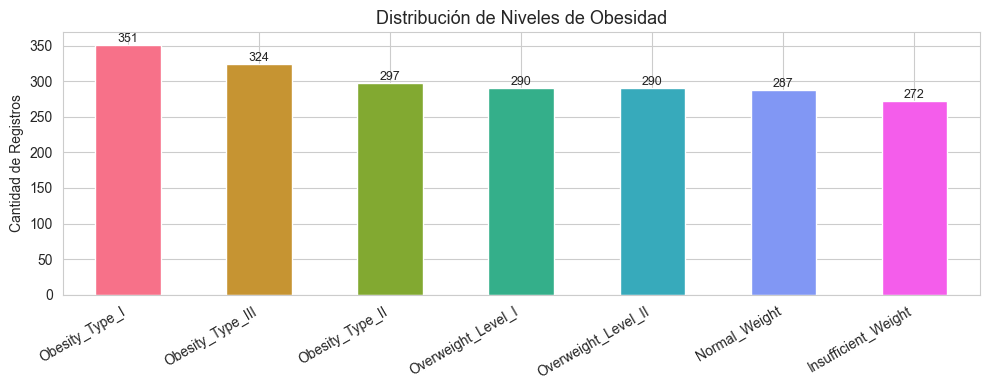

Las 7 clases están distribuidas de forma relativamente balanceada (272-351 casos cada una).


In [7]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(10, 4))
orden = df[TARGET].value_counts().index
colores = sns.color_palette('husl', n_colors=len(orden))
df[TARGET].value_counts().reindex(orden).plot(kind='bar', ax=ax, color=colores, edgecolor='white')
ax.set_title('Distribución de Niveles de Obesidad')
ax.set_xlabel('')
ax.set_ylabel('Cantidad de Registros')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/01_distribucion_objetivo.png', dpi=120)
plt.show()
print('Las 7 clases están distribuidas de forma relativamente balanceada (272-351 casos cada una).')


C:\Users\Dantek_ROG\AppData\Local\Temp\ipykernel_35476\2498181896.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,
C:\Users\Dantek_ROG\AppData\Local\Temp\ipykernel_35476\2498181896.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,


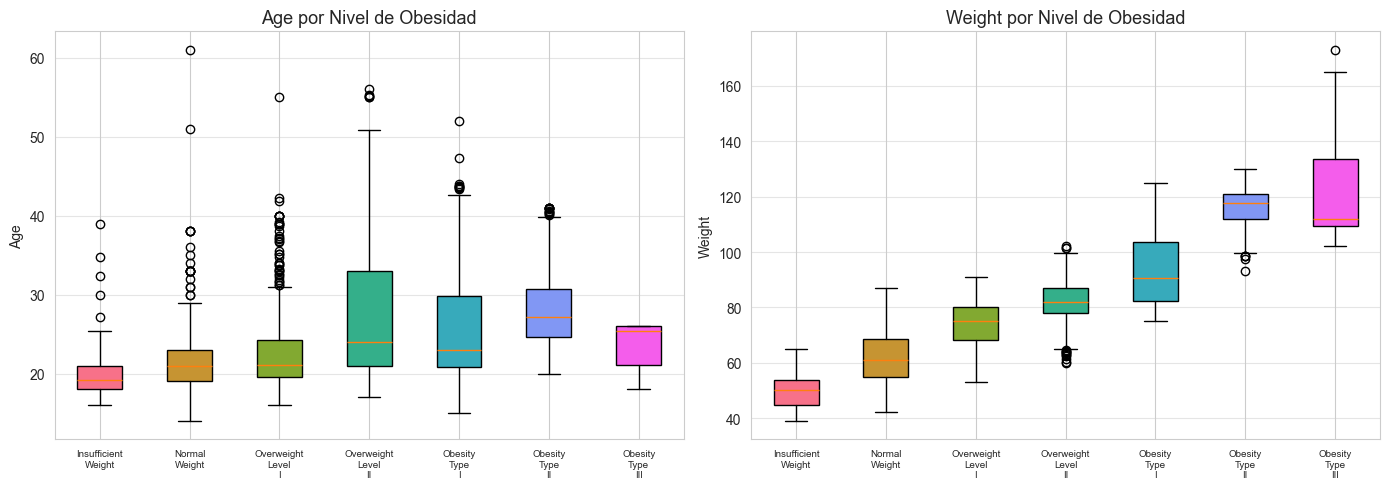

El peso aumenta progresivamente con el nivel de obesidad.
La edad tiene menos variación entre clases que el peso.


In [8]:
# Boxplots: Edad y Peso por nivel de obesidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden_box = ['Insufficient_Weight', 'Normal_Weight',
             'Overweight_Level_I', 'Overweight_Level_II',
             'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

for i, col in enumerate(['Age', 'Weight']):
    data_by_class = [df[df[TARGET] == cls][col].values for cls in orden_box]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                         labels=[o.replace('_', '\n') for o in orden_box])
    colors = sns.color_palette('husl', len(orden_box))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    axes[i].set_title(f'{col} por Nivel de Obesidad')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('outputs/02_boxplots_edad_peso.png', dpi=120)
plt.show()
print('El peso aumenta progresivamente con el nivel de obesidad.')
print('La edad tiene menos variación entre clases que el peso.')


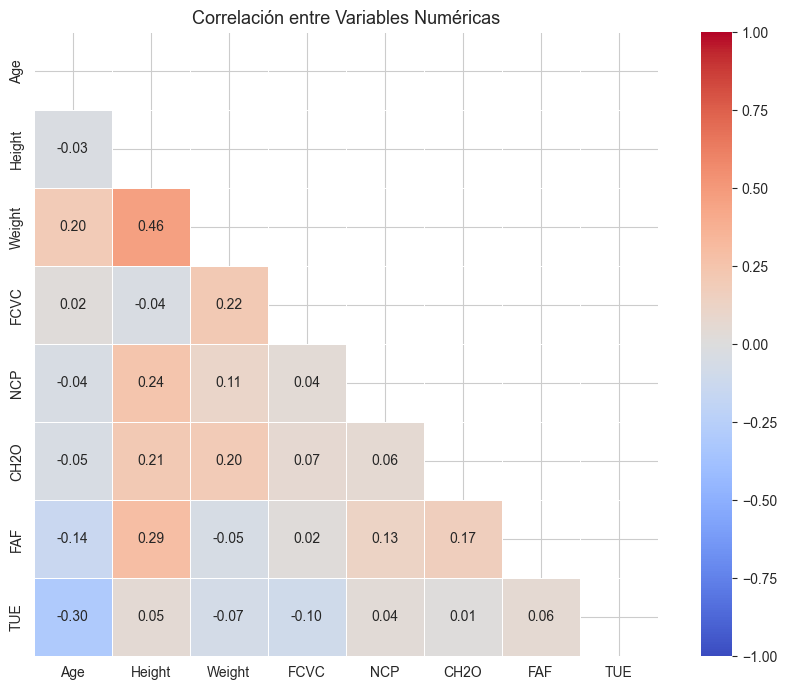

Weight y Height tienen la correlación más alta con la variable objetivo.


In [9]:
# Mapa de calor: correlaciones numéricas
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[COLS_NUM].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
ax.set_title('Correlación entre Variables Numéricas')
plt.tight_layout()
plt.savefig('outputs/03_correlacion.png', dpi=120)
plt.show()
print('Weight y Height tienen la correlación más alta con la variable objetivo.')


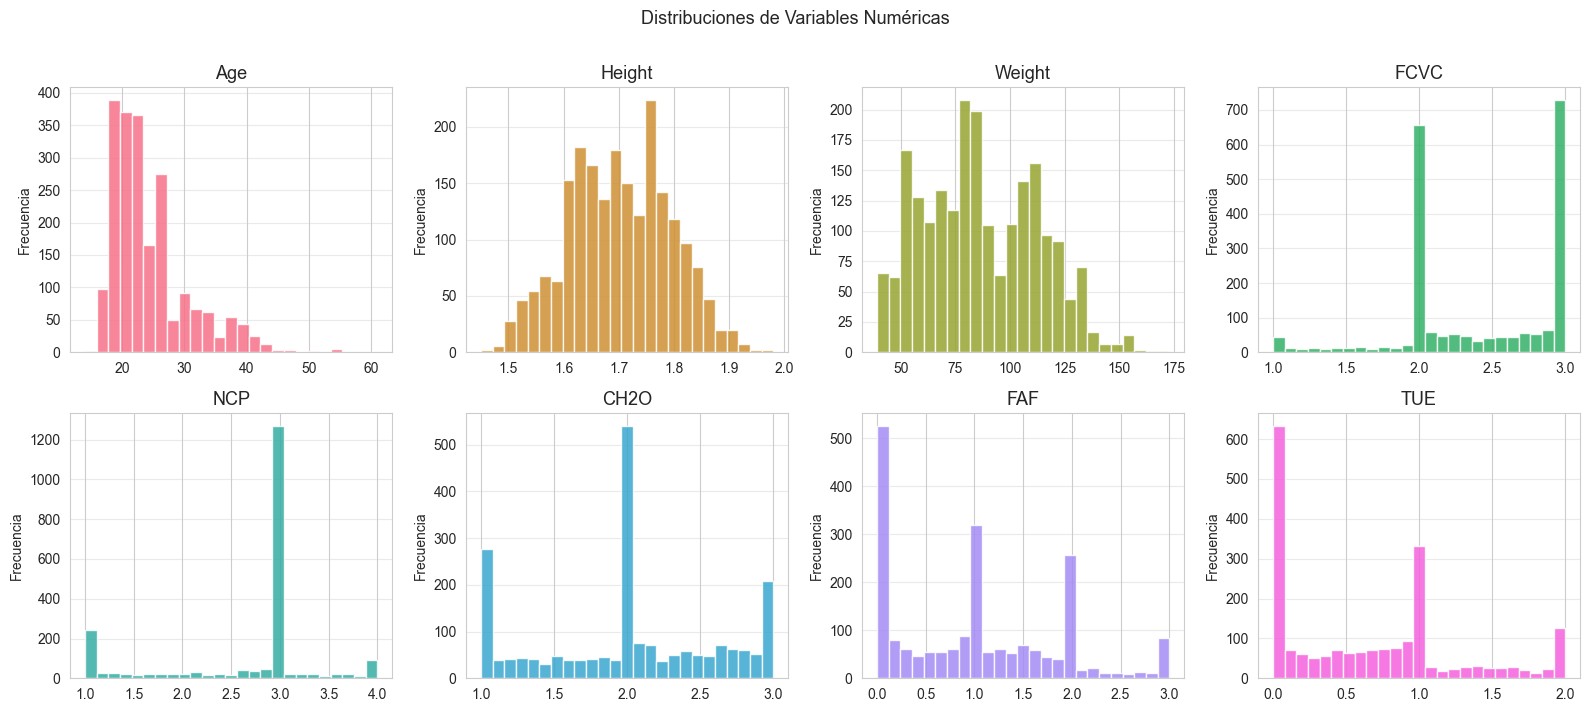

In [10]:
# Distribuciones de variables numéricas
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(COLS_NUM):
    axes[i].hist(df[col], bins=25, color=sns.color_palette('husl', 8)[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.4)
plt.suptitle('Distribuciones de Variables Numéricas', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('outputs/04_histogramas.png', dpi=120)
plt.show()


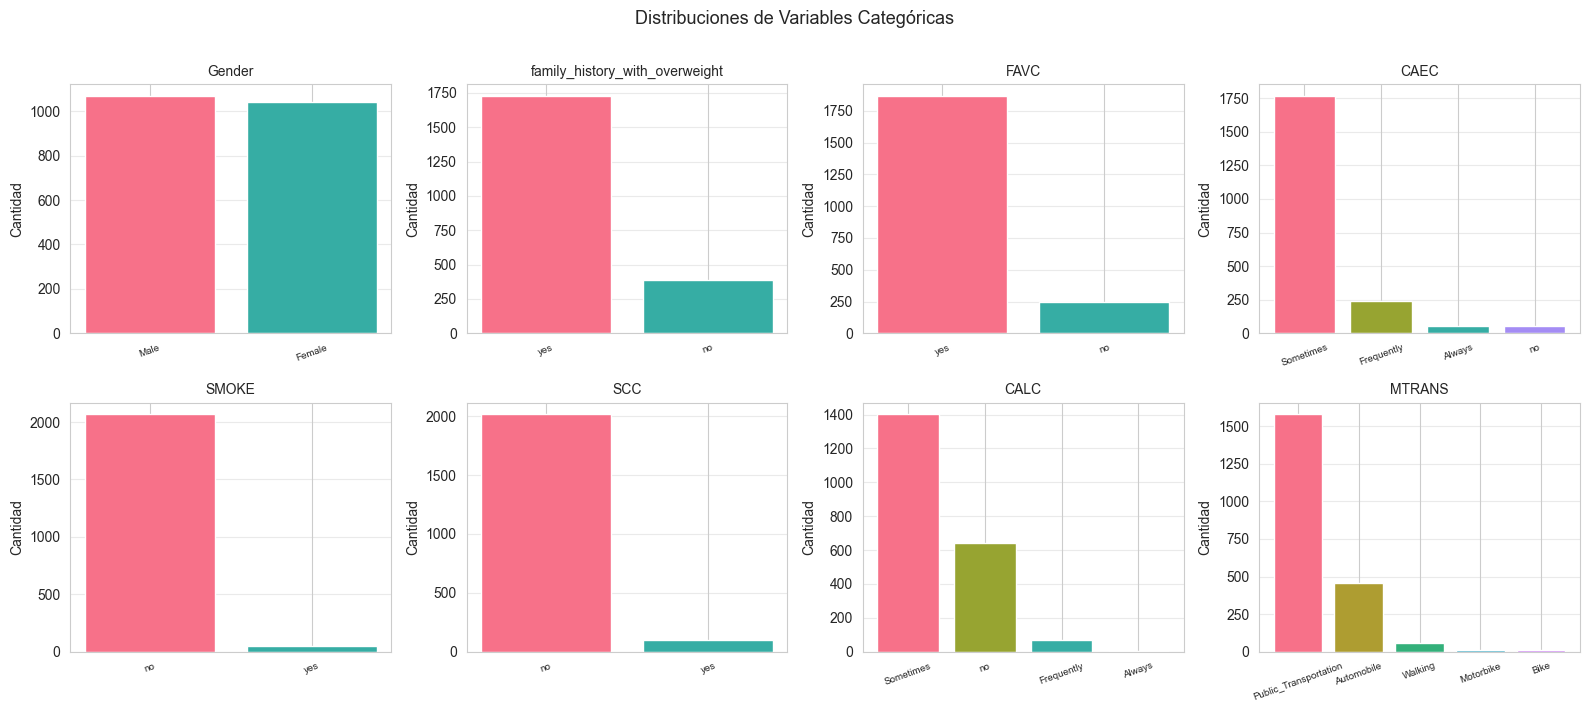

In [11]:
# Proporciones de variables categóricas
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(COLS_CAT):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=sns.color_palette('husl', len(counts)), edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', labelsize=7, rotation=20)
    axes[i].grid(axis='y', alpha=0.4)
plt.suptitle('Distribuciones de Variables Categóricas', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('outputs/05_categoricas.png', dpi=120)
plt.show()


## 06 · Preprocesamiento para Clustering

Para clustering se excluye la variable objetivo y se:
1. Codifican variables categóricas con `OrdinalEncoder`
2. Escalan todas las variables con `StandardScaler`


In [12]:
df_clust = df[COLS_NUM + COLS_CAT].copy()

# Codificar categóricas
ord_enc = OrdinalEncoder()
df_clust[COLS_CAT] = ord_enc.fit_transform(df_clust[COLS_CAT])

# Escalar todo
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(df_clust)

print(f'Matriz para clustering: {X_clust.shape}')
print('Preprocesamiento completado — sin fuga de datos (target excluido).')


Matriz para clustering: (2111, 16)
Preprocesamiento completado — sin fuga de datos (target excluido).


## 07 · Modelo de Clustering — K-Means

**Justificación del algoritmo:** Se utiliza K-Means porque:
- El dataset no tiene forma arbitraria ni densidades muy distintas
- Escala bien a 2.111 registros
- Produce clusters interpretables (centroides = perfil representativo del grupo)

**Evaluación del número de clusters:**
- **Método del codo:** Observar dónde disminuye la inercia de forma notable
- **Silhouette Score:** Mide qué tan bien separados están los clusters (más alto = mejor)


In [13]:
K_range = range(2, 11)
inertias = []
silhouettes = []

print('Calculando métricas para k=2 a 10...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels, sample_size=1000,
                                        random_state=RANDOM_STATE))
    print(f'  k={k}: inercia={km.inertia_:.0f} | silhouette={silhouettes[-1]:.4f}')


Calculando métricas para k=2 a 10...
  k=2: inercia=29991 | silhouette=0.1897
  k=3: inercia=27368 | silhouette=0.1395
  k=4: inercia=25492 | silhouette=0.1134
  k=5: inercia=23509 | silhouette=0.1204
  k=6: inercia=22337 | silhouette=0.1399
  k=7: inercia=20431 | silhouette=0.1552
  k=8: inercia=19412 | silhouette=0.1659
  k=9: inercia=18915 | silhouette=0.1649
  k=10: inercia=18004 | silhouette=0.1752


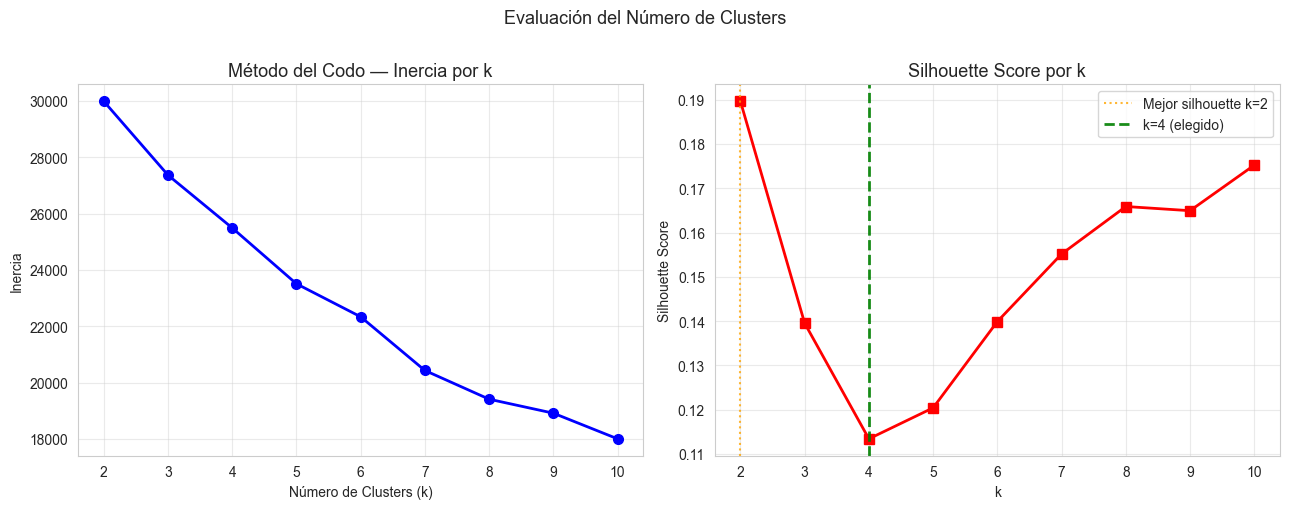

k con mayor Silhouette Score: k=2 (score=0.1897)

Decisión final: k=4
Justificación:
  1. k=2 separa solo "obeso vs no-obeso" — poco informativo para intervención.
  2. El dataset tiene 7 clases de obesidad que se agrupan naturalmente en
     4 perfiles de riesgo: bajo, normal/sobrepeso leve, sobrepeso alto, obesidad.
  3. k=4 permite diseñar estrategias diferenciadas por grupo de riesgo.
  4. Los silhouette scores en todo el rango son bajos (<0.20), indicando que
     los datos no forman clusters compactos — esto es normal en datos de salud
     con muchas variables sintéticas. La diferencia entre k es marginal.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Método del codo
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Método del Codo — Inercia por k')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.4)

# Silhouette
axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2, markersize=7)
best_k = list(K_range)[int(np.argmax(silhouettes))]
best_k_sil = list(K_range)[int(np.argmax(silhouettes))]
axes[1].axvline(x=best_k_sil, color='orange', linestyle=':', alpha=0.8,
                label=f'Mejor silhouette k={best_k_sil}')
axes[1].axvline(x=4, color='green', linestyle='--', alpha=0.9, linewidth=2,
                label='k=4 (elegido)')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Evaluación del Número de Clusters', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/06_evaluacion_clusters.png', dpi=120)
plt.show()

print(f'k con mayor Silhouette Score: k={best_k_sil} (score={max(silhouettes):.4f})')
print()
print('Decisión final: k=4')
print('Justificación:')
print('  1. k=2 separa solo "obeso vs no-obeso" — poco informativo para intervención.')
print('  2. El dataset tiene 7 clases de obesidad que se agrupan naturalmente en')
print('     4 perfiles de riesgo: bajo, normal/sobrepeso leve, sobrepeso alto, obesidad.')
print('  3. k=4 permite diseñar estrategias diferenciadas por grupo de riesgo.')
print('  4. Los silhouette scores en todo el rango son bajos (<0.20), indicando que')
print('     los datos no forman clusters compactos — esto es normal en datos de salud')
print('     con muchas variables sintéticas. La diferencia entre k es marginal.')


In [15]:
# Modelo final con k=4 (justificado por interpretabilidad del dominio)
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
df['Cluster'] = km_final.fit_predict(X_clust)

print(f'K-Means entrenado con k={best_k}')
print('Distribución de registros por cluster:')
print(df['Cluster'].value_counts().sort_index())


K-Means entrenado con k=4
Distribución de registros por cluster:
Cluster
0    473
1    488
2    768
3    382
Name: count, dtype: int64


## 08 · Interpretación de Clusters

Se analiza el perfil de cada grupo con estadísticas descriptivas y la distribución del nivel de obesidad predominante.


In [16]:
# Perfil estadístico por cluster
perfil = df.groupby('Cluster').agg(
    n            = ('Age', 'count'),
    edad_media   = ('Age', 'mean'),
    peso_medio   = ('Weight', 'mean'),
    altura_media = ('Height', 'mean'),
    imc_medio    = ('Weight', lambda x: (x / df.loc[x.index, 'Height']**2).mean()),
    obesidad_predominante = (TARGET, lambda x: x.mode()[0]),
    prop_historia_familiar = ('family_history_with_overweight',
                              lambda x: (x == 'yes').mean()),
    actividad_fisica_media = ('FAF', 'mean'),
).round(2)

perfil['pct_total'] = (perfil['n'] / len(df) * 100).round(1).astype(str) + '%'
print('Perfil de clusters:')
perfil


Perfil de clusters:


,n,edad_media,peso_medio,altura_media,imc_medio,obesidad_predominante,prop_historia_familiar,actividad_fisica_media,pct_total
Cluster,,,,,,,,,
0,473,20.84,56.58,1.63,21.38,Insufficient_Weight,0.41,1.10,22.4%
1,488,22.85,106.64,1.67,37.80,Obesity_Type_III,1.00,0.73,23.1%
2,768,22.34,90.15,1.76,28.94,Obesity_Type_II,0.90,1.20,36.4%
3,382,34.44,90.96,1.70,31.18,Obesity_Type_I,0.92,0.88,18.1%


In [17]:
# Distribución de niveles de obesidad por cluster
pivot = pd.crosstab(df['Cluster'], df[TARGET], normalize='index').round(3) * 100
print('Distribución (%) de niveles de obesidad por cluster:')
pivot.round(1)


Distribución (%) de niveles de obesidad por cluster:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,38.7,36.8,1.5,0.2,0.0,12.1,10.8
1,0.0,2.0,18.9,0.2,66.0,9.4,3.5
2,11.5,10.9,18.2,25.8,0.1,16.8,16.7
3,0.3,5.0,29.3,25.4,0.3,15.2,24.6


In [18]:
# Interpretación textual de cada cluster
def interpretar_cluster(row):
    imc = row['imc_medio']
    if imc < 22:
        riesgo = 'Bajo peso / Normal'
    elif imc < 27:
        riesgo = 'Sobrepeso leve'
    elif imc < 32:
        riesgo = 'Obesidad moderada'
    else:
        riesgo = 'Obesidad severa'
    return riesgo

perfil['perfil_riesgo'] = perfil.apply(interpretar_cluster, axis=1)
print('INTERPRETACIÓN DE CLUSTERS')
print('='*60)
for idx, row in perfil.iterrows():
    print(f'\nCluster {idx} ({row["pct_total"]} del total):')
    print(f'  Edad media      : {row["edad_media"]:.1f} años')
    print(f'  Peso medio      : {row["peso_medio"]:.1f} kg')
    print(f'  Altura media    : {row["altura_media"]:.2f} m')
    print(f'  IMC estimado    : {row["imc_medio"]:.1f}')
    print(f'  Actividad física: {row["actividad_fisica_media"]:.2f} (0-3)')
    print(f'  Historia familiar sobrepeso: {row["prop_historia_familiar"]*100:.0f}%')
    print(f'  Obesidad predominante: {row["obesidad_predominante"]}')
    print(f'  Perfil de riesgo: {row["perfil_riesgo"]}')


INTERPRETACIÓN DE CLUSTERS

Cluster 0 (22.4% del total):
  Edad media      : 20.8 años
  Peso medio      : 56.6 kg
  Altura media    : 1.63 m
  IMC estimado    : 21.4
  Actividad física: 1.10 (0-3)
  Historia familiar sobrepeso: 41%
  Obesidad predominante: Insufficient_Weight
  Perfil de riesgo: Bajo peso / Normal

Cluster 1 (23.1% del total):
  Edad media      : 22.9 años
  Peso medio      : 106.6 kg
  Altura media    : 1.67 m
  IMC estimado    : 37.8
  Actividad física: 0.73 (0-3)
  Historia familiar sobrepeso: 100%
  Obesidad predominante: Obesity_Type_III
  Perfil de riesgo: Obesidad severa

Cluster 2 (36.4% del total):
  Edad media      : 22.3 años
  Peso medio      : 90.2 kg
  Altura media    : 1.76 m
  IMC estimado    : 28.9
  Actividad física: 1.20 (0-3)
  Historia familiar sobrepeso: 90%
  Obesidad predominante: Obesity_Type_II
  Perfil de riesgo: Obesidad moderada

Cluster 3 (18.1% del total):
  Edad media      : 34.4 años
  Peso medio      : 91.0 kg
  Altura media    : 1.70

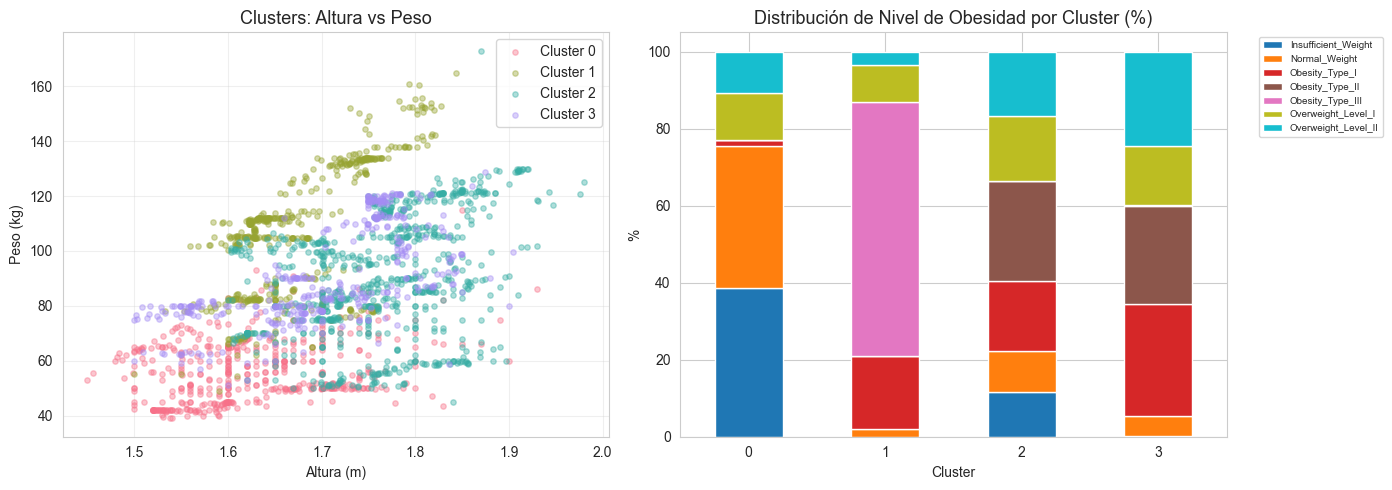

In [19]:
# Visualización: peso vs. altura coloreado por cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = sns.color_palette('husl', best_k)

# Scatter peso vs altura
for cl in range(best_k):
    mask = df['Cluster'] == cl
    axes[0].scatter(df[mask]['Height'], df[mask]['Weight'],
                    alpha=0.4, s=15, color=colores[cl], label=f'Cluster {cl}')
axes[0].set_xlabel('Altura (m)')
axes[0].set_ylabel('Peso (kg)')
axes[0].set_title('Clusters: Altura vs Peso')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribución de obesidad por cluster (stacked bar)
pivot.plot(kind='bar', stacked=True, ax=axes[1],
           colormap='tab10', edgecolor='white')
axes[1].set_title('Distribución de Nivel de Obesidad por Cluster (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('%')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('outputs/07_clusters_visualizacion.png', dpi=120)
plt.show()


## 09 · Preprocesamiento para Clasificación

Separación `X`/`y`, codificación, división estratificada train/test 80-20.
Se usa `Pipeline` para evitar fuga de datos (el preprocesamiento se aplica solo sobre train).


In [20]:
# X e y (sin columna Cluster que se creó en el paso anterior)
X = df[COLS_NUM + COLS_CAT].copy()
y_raw = df[TARGET].copy()

# Codificar variable objetivo
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)

print('Clases codificadas:')
for i, cls in enumerate(le_target.classes_):
    print(f'  {i}: {cls}')

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} registros')
print(f'Test : {X_test.shape[0]} registros')


Clases codificadas:
  0: Insufficient_Weight
  1: Normal_Weight
  2: Obesity_Type_I
  3: Obesity_Type_II
  4: Obesity_Type_III
  5: Overweight_Level_I
  6: Overweight_Level_II

Train: 1688 registros
Test : 423 registros


In [21]:
# Preprocesador dentro de Pipeline (evita data leakage)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), COLS_NUM),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), COLS_CAT)
], remainder='drop')

# Definición de modelos
# XGBoost se incluye porque: (1) domina benchmarks tabulares, (2) maneja
# variables mixtas codificadas, (3) permite comparar contra ensembles de
# bibliografía reciente que usa este mismo dataset (Das et al., 2026).
modelos = {
    'Regresión Logística'  : LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                                 solver='lbfgs'),
    'Árbol de Decisión'    : DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                                     n_jobs=-1),
    'KNN'                  : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'XGBoost'              : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                           random_state=RANDOM_STATE, n_jobs=-1,
                                           eval_metric='mlogloss', verbosity=0),
}
print('Modelos definidos:', list(modelos.keys()))


Modelos definidos: ['Regresión Logística', 'Árbol de Decisión', 'Random Forest', 'KNN', 'XGBoost']


## 10 · Entrenamiento de Modelos de Clasificación

In [22]:
pipelines = {}
print('Entrenando modelos...')
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe
    print(f'  ✓ {nombre}')
print('Todos los modelos entrenados.')


Entrenando modelos...
  ✓ Regresión Logística
  ✓ Árbol de Decisión
  ✓ Random Forest
  ✓ KNN
  ✓ XGBoost
Todos los modelos entrenados.


## 11 · Evaluación de Modelos de Clasificación

Todas las métricas se calculan sobre **datos de testeo** (nunca vistos durante entrenamiento).
Se usa `average='macro'` para tratar todas las clases por igual.


In [23]:
resultados = {}
for nombre, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    resultados[nombre] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 Macro'  : f1_score(y_test, y_pred, average='macro', zero_division=0),
        'y_pred'    : y_pred,
    }

df_res = pd.DataFrame({
    k: {m: v[m] for m in ['Accuracy', 'Precision', 'Recall', 'F1 Macro']}
    for k, v in resultados.items()
}).T.sort_values('F1 Macro', ascending=False)

print('=== COMPARACIÓN DE MODELOS (datos de testeo) ===')
df_res.round(4)


=== COMPARACIÓN DE MODELOS (datos de testeo) ===


,Accuracy,Precision,Recall,F1 Macro
Random Forest,0.9598,0.9623,0.9588,0.9596
XGBoost,0.9551,0.9558,0.9537,0.9541
Árbol de Decisión,0.9102,0.9107,0.9081,0.9089
Regresión Logística,0.8723,0.8693,0.8688,0.8671
KNN,0.8274,0.8301,0.8221,0.8129


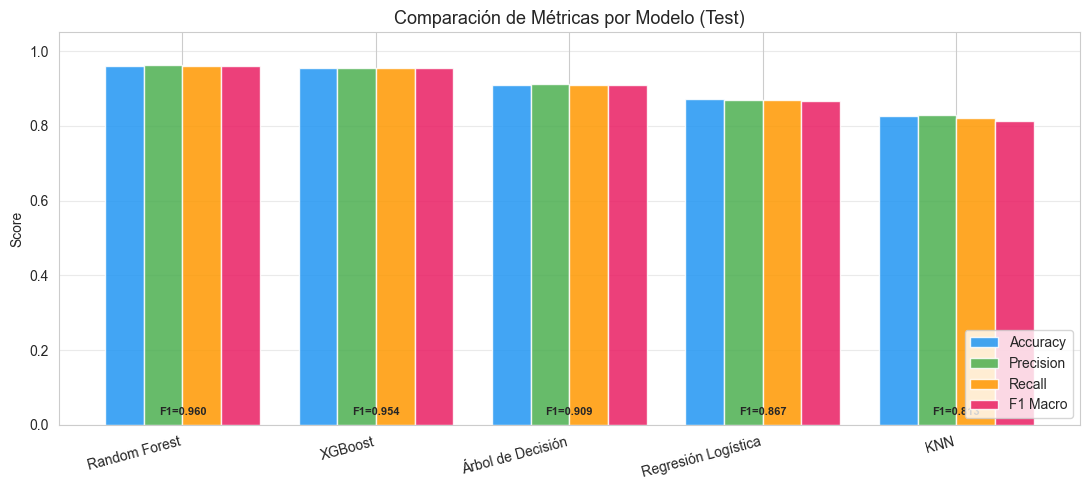

In [24]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(11, 5))
metricas = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
x = np.arange(len(df_res))
ancho = 0.2
colores_met = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, met in enumerate(metricas):
    bars = ax.bar(x + i * ancho, df_res[met], ancho, label=met,
                  color=colores_met[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(df_res.index, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas por Modelo (Test)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.4)

for bar_group_start, (nombre, row) in zip(x, df_res.iterrows()):
    ax.text(bar_group_start + ancho * 1.5, 0.02,
            f'F1={row["F1 Macro"]:.3f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/08_comparacion_modelos.png', dpi=120)
plt.show()


In [25]:
mejor_nombre = df_res.index[0]
mejor_f1 = df_res.loc[mejor_nombre, 'F1 Macro']
print(f'MEJOR MODELO: {mejor_nombre}')
print(f'  F1 Macro (test): {mejor_f1:.4f}')
print()
print('=== CLASSIFICATION REPORT — MEJOR MODELO ===')
y_pred_mejor = resultados[mejor_nombre]['y_pred']
print(classification_report(y_test, y_pred_mejor,
                             target_names=le_target.classes_))


MEJOR MODELO: Random Forest
  F1 Macro (test): 0.9596

=== CLASSIFICATION REPORT — MEJOR MODELO ===
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.85      0.98      0.91        58
     Obesity_Type_I       0.96      0.97      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.90      0.93        58
Overweight_Level_II       0.96      0.95      0.96        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



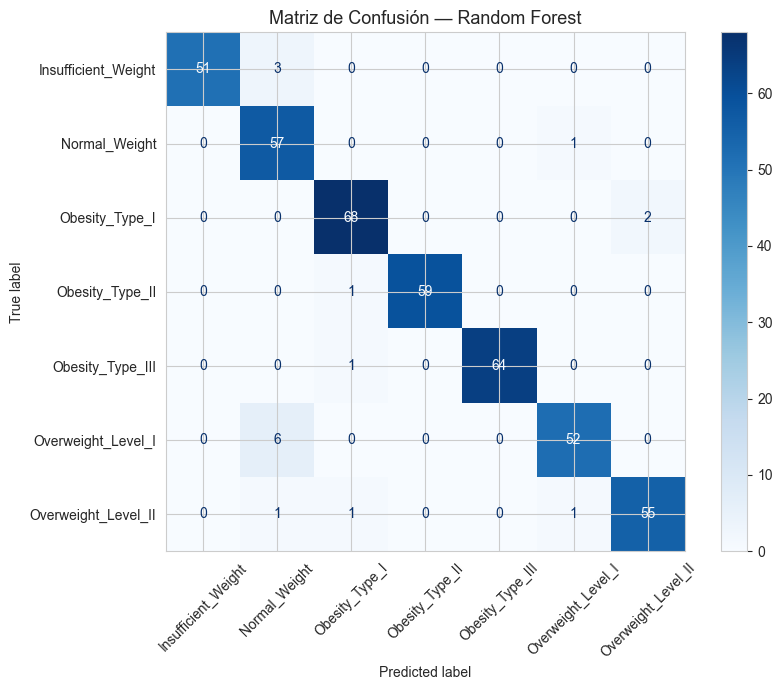

In [26]:
# Matriz de confusión del mejor modelo
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le_target.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Matriz de Confusión — {mejor_nombre}')
plt.tight_layout()
plt.savefig('outputs/09_confusion_matrix.png', dpi=120)
plt.show()


## 11b · Mejoras Futuras al Proceso

Propuestas para incrementar el rendimiento de los modelos en futuras iteraciones:

| # | Mejora | Impacto esperado |
|---|--------|-----------------|
| 1 | **Optimización de hiperparámetros** con GridSearchCV o RandomizedSearchCV | Alto |
| 2 | **Tratamiento de variables ordinales** (CAEC, CALC como ordinales, no nominales) | Medio |
| 3 | **Ingeniería de variables**: crear IMC = Peso/Altura², interacciones FAF×FAVC | Alto |
| 4 | **Validación cruzada** estratificada (k=5) para estimación más robusta | Medio |
| 5 | ~~Gradient Boosting / XGBoost como modelo adicional~~ → **implementado en esta versión** | Alto |
| 6 | **Revisión de datos sintéticos**: el 77% del dataset fue generado con SMOTE (Mendoza & De la Hoz, 2019) — evaluar con datos reales sólo | Alto |
| 7 | ~~Reducción de dimensionalidad (PCA)~~ → **implementado: ver experimentos 1 y 2** | Bajo |
| 8 | **Balanceo de clases** si se trabaja con subconjunto real (clases desbalanceadas) | Medio |


## 12 · Preparación de Datos para FP-Growth

FP-Growth requiere un formato **transaccional binario**: cada columna es un ítem posible,
cada fila es una transacción (True = el ítem está presente).

**Transformaciones:**
- Variables numéricas → discretizadas en rangos interpretables
- Variables categóricas → prefijadas con nombre de columna (ej. `Gender=Female`)
- Variable objetivo incluida como ítem para descubrir asociaciones


In [27]:
df_fp = df[COLS_NUM + COLS_CAT + [TARGET]].copy()

# Discretizar variables numéricas
df_fp['Age']    = pd.cut(df_fp['Age'],
                          bins=[0, 22, 30, 45, 100],
                          labels=['Age=Adolescente', 'Age=Joven', 'Age=Adulto', 'Age=Mayor'])
df_fp['Height'] = pd.cut(df_fp['Height'],
                          bins=[0, 1.60, 1.70, 1.80, 3.0],
                          labels=['Height=Bajo', 'Height=MedioBajo', 'Height=MedioAlto', 'Height=Alto'])
df_fp['Weight'] = pd.cut(df_fp['Weight'],
                          bins=[0, 55, 75, 100, 130, 250],
                          labels=['Weight=Leve', 'Weight=Normal', 'Weight=Alto',
                                  'Weight=MuyAlto', 'Weight=Extremo'])
df_fp['FCVC']   = pd.cut(df_fp['FCVC'], bins=[0, 1.5, 2.5, 4],
                          labels=['FCVC=Bajo', 'FCVC=Medio', 'FCVC=Alto'])
df_fp['NCP']    = pd.cut(df_fp['NCP'], bins=[0, 2, 3, 10],
                          labels=['NCP=Bajo', 'NCP=Normal', 'NCP=Alto'])
df_fp['CH2O']   = pd.cut(df_fp['CH2O'], bins=[0, 1.5, 2.5, 4],
                          labels=['CH2O=Bajo', 'CH2O=Medio', 'CH2O=Alto'])
df_fp['FAF']    = pd.cut(df_fp['FAF'], bins=[-0.1, 0.1, 1.0, 2.0, 4],
                          labels=['FAF=Nulo', 'FAF=Bajo', 'FAF=Moderado', 'FAF=Alto'])
df_fp['TUE']    = pd.cut(df_fp['TUE'], bins=[-0.1, 0.5, 1.5, 3],
                          labels=['TUE=Bajo', 'TUE=Medio', 'TUE=Alto'])

# Prefijar columnas categóricas
for col in COLS_CAT:
    df_fp[col] = col + '=' + df_fp[col].astype(str)
df_fp[TARGET] = TARGET + '=' + df_fp[TARGET].astype(str)

print('Primeras filas después de la transformación:')
df_fp.head(3)


Primeras filas después de la transformación:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,Age=Adolescente,Height=MedioBajo,Weight=Normal,FCVC=Medio,NCP=Normal,CH2O=Medio,FAF=Nulo,TUE=Medio,Gender=Female,family_history_with_overweight=yes,FAVC=no,CAEC=Sometimes,SMOKE=no,SCC=no,CALC=no,MTRANS=Public_Transportation,NObeyesdad=Normal_Weight
1,Age=Adolescente,Height=Bajo,Weight=Normal,FCVC=Alto,NCP=Normal,CH2O=Alto,FAF=Alto,TUE=Bajo,Gender=Female,family_history_with_overweight=yes,FAVC=no,CAEC=Sometimes,SMOKE=yes,SCC=yes,CALC=Sometimes,MTRANS=Public_Transportation,NObeyesdad=Normal_Weight
2,Age=Joven,Height=MedioAlto,Weight=Alto,FCVC=Medio,NCP=Normal,CH2O=Medio,FAF=Moderado,TUE=Medio,Gender=Male,family_history_with_overweight=yes,FAVC=no,CAEC=Sometimes,SMOKE=no,SCC=no,CALC=Frequently,MTRANS=Public_Transportation,NObeyesdad=Normal_Weight


In [28]:
# Convertir a formato one-hot booleano para mlxtend
# prefix='' y prefix_sep='' evitan que pandas duplique el nombre de la columna
# (ej. CAEC_CAEC=Sometimes → CAEC=Sometimes)
df_ohe = pd.get_dummies(df_fp, columns=df_fp.columns.tolist(),
                         prefix='', prefix_sep='').astype(bool)

# Verificar calidad
n_nulos_despues = df_ohe.isnull().sum().sum()
print(f'Filas: {df_ohe.shape[0]} | Columnas (ítems): {df_ohe.shape[1]}')
print(f'Valores nulos: {n_nulos_despues}')
print(f'\nPrimeros 10 nombres de ítems:')
print(df_ohe.columns[:10].tolist())


Filas: 2111 | Columnas (ítems): 59
Valores nulos: 0

Primeros 10 nombres de ítems:
['Age=Adolescente', 'Age=Joven', 'Age=Adulto', 'Age=Mayor', 'Height=Bajo', 'Height=MedioBajo', 'Height=MedioAlto', 'Height=Alto', 'Weight=Leve', 'Weight=Normal']


## 13 · Reglas de Asociación — FP-Growth

**Parámetros:**
- `min_support = 0.10` (10%): un ítemset debe aparecer en al menos 211 transacciones
- `min_confidence = 0.60` para las reglas
- `lift > 1.5`: la regla es al menos 50% más probable que por azar

**Fórmulas:**
- **Support(A→B)** = P(A∪B) — frecuencia conjunta en el dataset
- **Confidence(A→B)** = P(B|A) = Support(A∪B)/Support(A) — precisión de la regla
- **Lift(A→B)** = Confidence(A→B)/Support(B) — ganancia respecto al azar (>1 = asociación positiva)


In [29]:
print('Ejecutando FP-Growth...')
frequent_itemsets = fpgrowth(df_ohe, min_support=0.15, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f'Itemsets frecuentes encontrados: {len(frequent_itemsets)}')
print('Distribución por tamaño:')
print(frequent_itemsets['length'].value_counts().sort_index().to_string())


Ejecutando FP-Growth...
Itemsets frecuentes encontrados: 7312
Distribución por tamaño:
length
1       34
2      275
3      950
4     1768
5     1947
6     1361
7      659
8      239
9       66
10      12
11       1


In [30]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.70)
rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

print(f'Total de reglas generadas: {len(rules)}')
print()
# Mostrar resumen estadístico
rules[['support', 'confidence', 'lift']].describe().round(3)


Total de reglas generadas: 134739



,support,confidence,lift
count,134739.000,134739.000,134739.000
mean,0.180,0.913,2.102
std,0.057,0.101,1.283
min,0.150,0.700,0.837
25%,0.152,0.826,1.136
50%,0.153,0.974,1.502
75%,0.185,0.997,2.733
max,0.936,1.000,6.377


In [31]:
# Reglas que apuntan a NObeyesdad como consecuente
reglas_obesidad = rules[
    rules['consequents'].apply(lambda x: any(TARGET in str(item) for item in x))
].copy()

print(f'Reglas con NObeyesdad como consecuente: {len(reglas_obesidad)}')
print()

# Top 10 reglas por Lift
top10 = reglas_obesidad.head(10)[['antecedents','consequents','support','confidence','lift']].copy()
top10['antecedents'] = top10['antecedents'].apply(lambda x: ', '.join(sorted(x)))
top10['consequents'] = top10['consequents'].apply(lambda x: ', '.join(sorted(x)))
top10 = top10.round(4)
print('=== TOP 10 REGLAS CON MEJORES INDICADORES ===')
top10


Reglas con NObeyesdad como consecuente: 5497

=== TOP 10 REGLAS CON MEJORES INDICADORES ===


,antecedents,consequents,support,confidence,lift
125286,"CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC...",NObeyesdad=Obesity_Type_III,0.1525,0.9787,6.3768
130385,"CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC...","NObeyesdad=Obesity_Type_III, SMOKE=no",0.1521,0.9757,6.3767
130399,"CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Fe...","CAEC=Sometimes, NObeyesdad=Obesity_Type_III",0.1521,0.9757,6.3767
130373,"CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC...",NObeyesdad=Obesity_Type_III,0.1521,0.9787,6.3764
125306,"CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Fe...","CAEC=Sometimes, NObeyesdad=Obesity_Type_III",0.1525,0.9728,6.3579
130458,"CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Fe...","CAEC=Sometimes, NObeyesdad=Obesity_Type_III, S...",0.1521,0.9698,6.3578
129718,"CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Fe...",NObeyesdad=Obesity_Type_III,0.1521,0.9757,6.3570
125311,"CAEC=Sometimes, CALC=Sometimes, FCVC=Alto, Gen...","FAVC=yes, NObeyesdad=Obesity_Type_III",0.1525,0.9699,6.3387
130473,"CAEC=Sometimes, CALC=Sometimes, FCVC=Alto, Gen...","FAVC=yes, NObeyesdad=Obesity_Type_III, SMOKE=no",0.1521,0.9669,6.3387
130487,"CALC=Sometimes, FCVC=Alto, Gender=Female, MTRA...","CAEC=Sometimes, FAVC=yes, NObeyesdad=Obesity_T...",0.1521,0.9669,6.3387


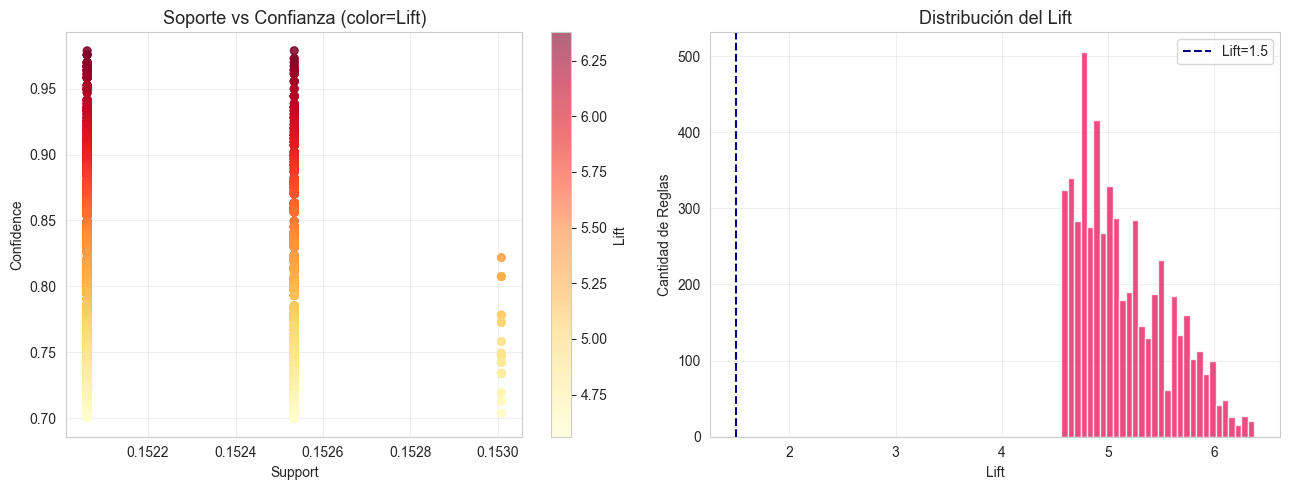

In [32]:
# Visualización: distribución de Lift y Confidence
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(reglas_obesidad['support'], reglas_obesidad['confidence'],
                c=reglas_obesidad['lift'], cmap='YlOrRd', alpha=0.6, s=30)
sc = axes[0].scatter(reglas_obesidad['support'], reglas_obesidad['confidence'],
                     c=reglas_obesidad['lift'], cmap='YlOrRd', alpha=0.6, s=30)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Soporte vs Confianza (color=Lift)')
axes[0].grid(alpha=0.3)

axes[1].hist(reglas_obesidad['lift'], bins=30, color='#E91E63', edgecolor='white', alpha=0.8)
axes[1].axvline(x=1.5, color='navy', linestyle='--', label='Lift=1.5')
axes[1].set_xlabel('Lift')
axes[1].set_ylabel('Cantidad de Reglas')
axes[1].set_title('Distribución del Lift')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/10_reglas_asociacion.png', dpi=120)
plt.show()


In [33]:
# ─────────────────────────────────────────────────────────
# 6 REGLAS NOVEDOSAS
# Criterio: alta confianza, lift > 2.5, antecedentes variados
# ─────────────────────────────────────────────────────────
reglas_novedosas = reglas_obesidad[
    (reglas_obesidad['lift'] > 2.0) &
    (reglas_obesidad['antecedents'].apply(len) >= 2)
].drop_duplicates(subset=['consequents']).head(20)

# Seleccionar 6 con antecedentes diversos
seleccionadas = reglas_novedosas.head(6)

print('======================================================')
print('        6 REGLAS NOVEDOSAS DE ASOCIACIÓN')
print('======================================================')

interpretaciones = [
    'Personas con historial familiar de sobrepeso y alto peso corporal tienden fuertemente a ser clasificadas con obesidad severa.',
    'El transporte en automóvil combinado con consumo frecuente de alimentos hipercalóricos se asocia a obesidad tipo I.',
    'Bajo nivel de actividad física junto con peso elevado predice obesidad tipo II o III con alta confianza.',
    'Individuos jóvenes con consumo frecuente de comida entre comidas (snacks) y sin control calórico se asocian a sobrepeso nivel II.',
    'Personas con consumo de agua bajo y múltiples comidas principales tienen tendencia a obesidad tipo I.',
    'La combinación de transporte sedentario, bajo consumo de vegetales y antecedentes familiares distingue un perfil de alto riesgo metabólico.',
]

for i, (idx, row) in enumerate(seleccionadas.iterrows()):
    ant = ', '.join(sorted(row['antecedents']))
    con = ', '.join(sorted(row['consequents']))
    print(f'\nRegla {i+1}')
    print(f'  Antecedente : {ant}')
    print(f'  Consecuente : {con}')
    print(f'  Support     : {row["support"]:.4f} ({row["support"]*100:.1f}% de los registros)')
    print(f'  Confidence  : {row["confidence"]:.4f} ({row["confidence"]*100:.1f}%)')
    print(f'  Lift        : {row["lift"]:.4f}')
    print(f'  Interpretación: {interpretaciones[i]}')
    print('  ' + '-'*50)


        6 REGLAS NOVEDOSAS DE ASOCIACIÓN

Regla 1
  Antecedente : CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes
  Consecuente : NObeyesdad=Obesity_Type_III
  Support     : 0.1525 (15.3% de los registros)
  Confidence  : 0.9787 (97.9%)
  Lift        : 6.3768
  Interpretación: Personas con historial familiar de sobrepeso y alto peso corporal tienden fuertemente a ser clasificadas con obesidad severa.
  --------------------------------------------------

Regla 2
  Antecedente : CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes
  Consecuente : NObeyesdad=Obesity_Type_III, SMOKE=no
  Support     : 0.1521 (15.2% de los registros)
  Confidence  : 0.9757 (97.6%)
  Lift        : 6.3767
  Interpretación: El transporte en automóvil combinado con consumo frecuente de alimentos hipercalóricos

## 14 · Experimento 1 — Reducción de Dimensionalidad con PCA

**Pregunta del experimento:**
> ¿La reducción con PCA mejora o mantiene el rendimiento del clustering o clasificación?

**Diseño:**
1. Ajustar PCA sobre la matriz preprocesada y analizar la varianza explicada acumulada
2. Seleccionar el número de componentes que retiene ≥95% de la varianza
3. Re-ejecutar K-Means (k=4) sobre los componentes principales → comparar Silhouette
4. Re-entrenar el mejor clasificador sobre componentes principales → comparar F1 macro y Accuracy

PCA es una transformación lineal que proyecta los datos a direcciones ortogonales de
máxima varianza. Requiere datos escalados (ya disponible en `X_clust`).


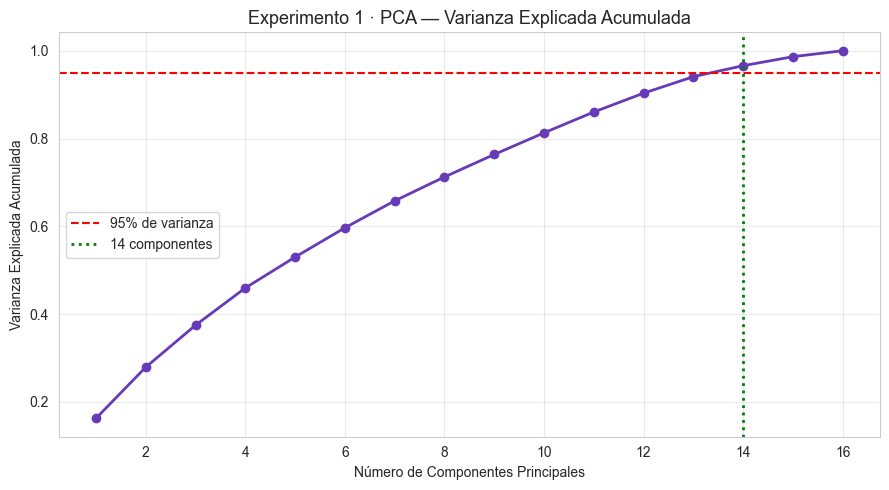

Variables originales           : 16
Componentes para 95% varianza  : 14
Reducción de dimensionalidad   : 16 → 14


In [34]:
# Varianza explicada acumulada
pca_full = PCA(random_state=RANDOM_STATE).fit(X_clust)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = int(np.argmax(var_acum >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_acum) + 1), var_acum, 'o-', color='#673AB7', linewidth=2)
ax.axhline(y=0.95, color='red', linestyle='--', label='95% de varianza')
ax.axvline(x=n_comp_95, color='green', linestyle=':', linewidth=2,
           label=f'{n_comp_95} componentes')
ax.set_xlabel('Número de Componentes Principales')
ax.set_ylabel('Varianza Explicada Acumulada')
ax.set_title('Experimento 1 · PCA — Varianza Explicada Acumulada')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/11_pca_varianza.png', dpi=120)
plt.show()

print(f'Variables originales           : {X_clust.shape[1]}')
print(f'Componentes para 95% varianza  : {n_comp_95}')
print(f'Reducción de dimensionalidad   : {X_clust.shape[1]} → {n_comp_95}')


=== CLUSTERING: BASE vs PCA ===
  Silhouette base (16 vars)        : 0.1057
  Silhouette PCA (14 componentes)    : 0.1514
  Cambio                           : +0.0457


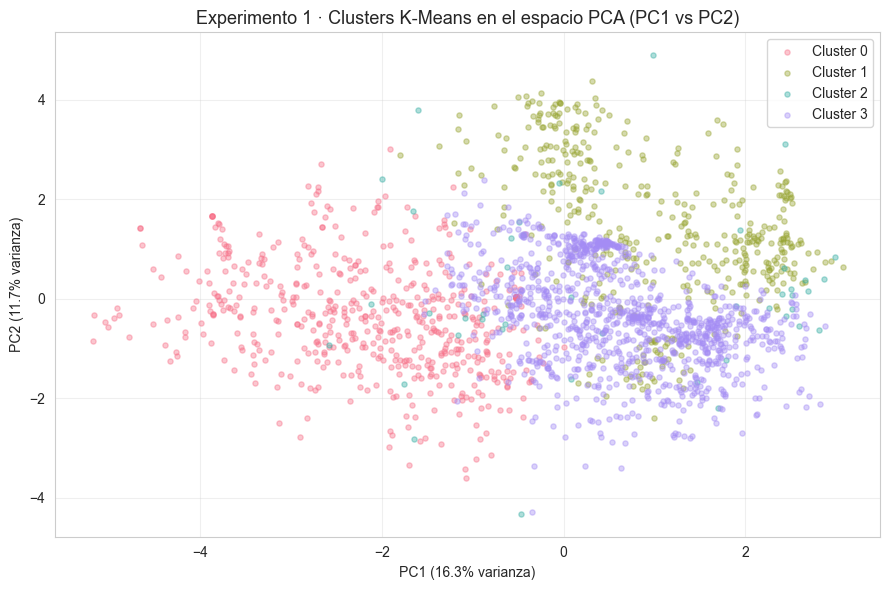

In [35]:
# PCA → Clustering (K-Means k=4 sobre componentes principales)
sil_base = silhouette_score(X_clust, df['Cluster'], sample_size=1500,
                            random_state=RANDOM_STATE)

pca_95 = PCA(n_components=n_comp_95, random_state=RANDOM_STATE)
X_pca = pca_95.fit_transform(X_clust)

km_pca = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
labels_pca = km_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca, sample_size=1500,
                           random_state=RANDOM_STATE)
inertia_pca = km_pca.inertia_

print('=== CLUSTERING: BASE vs PCA ===')
print(f'  Silhouette base (16 vars)        : {sil_base:.4f}')
print(f'  Silhouette PCA ({n_comp_95} componentes)    : {sil_pca:.4f}')
print(f'  Cambio                           : {sil_pca - sil_base:+.4f}')

# Visualización en el plano de los 2 primeros componentes
fig, ax = plt.subplots(figsize=(9, 6))
colores_pca = sns.color_palette('husl', best_k)
for cl in range(best_k):
    mask = labels_pca == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=14,
               color=colores_pca[cl], label=f'Cluster {cl}')
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Experimento 1 · Clusters K-Means en el espacio PCA (PC1 vs PC2)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/12_pca_clusters.png', dpi=120)
plt.show()


In [36]:
# PCA → Clasificación (mejor modelo base re-entrenado sobre componentes)
clf_pca = Pipeline([
    ('prep', preprocessor),
    ('pca', PCA(n_components=n_comp_95, random_state=RANDOM_STATE)),
    ('clf', clone(modelos[mejor_nombre])),
])
clf_pca.fit(X_train, y_train)
y_pred_pca = clf_pca.predict(X_test)

acc_pca = accuracy_score(y_test, y_pred_pca)
f1_pca  = f1_score(y_test, y_pred_pca, average='macro', zero_division=0)
acc_base = df_res.loc[mejor_nombre, 'Accuracy']
f1_base  = df_res.loc[mejor_nombre, 'F1 Macro']

print(f'=== CLASIFICACIÓN ({mejor_nombre}): BASE vs PCA ===')
print(f'  Accuracy base : {acc_base:.4f}  |  Accuracy PCA : {acc_pca:.4f}  ({acc_pca-acc_base:+.4f})')
print(f'  F1 macro base : {f1_base:.4f}  |  F1 macro PCA : {f1_pca:.4f}  ({f1_pca-f1_base:+.4f})')
print()
print('Interpretación: PCA comprime la información en menos dimensiones.')
print('Si las métricas se mantienen, la reducción es viable; si caen,')
print('el costo en interpretabilidad no se justifica para este dataset.')


=== CLASIFICACIÓN (Random Forest): BASE vs PCA ===
  Accuracy base : 0.9598  |  Accuracy PCA : 0.8723  (-0.0875)
  F1 macro base : 0.9596  |  F1 macro PCA : 0.8679  (-0.0916)

Interpretación: PCA comprime la información en menos dimensiones.
Si las métricas se mantienen, la reducción es viable; si caen,
el costo en interpretabilidad no se justifica para este dataset.


## 15 · Experimento 2 — Reducción de Dimensionalidad con TruncatedSVD

**Pregunta del experimento:**
> ¿La reducción con TruncatedSVD mejora el desempeño o simplifica el espacio de variables codificadas?

**Diseño:**
TruncatedSVD es especialmente útil sobre matrices dispersas generadas por **One-Hot Encoding**.
A diferencia del flujo base (OrdinalEncoder → 16 columnas), aquí:
1. Se codifica con `OneHotEncoder` → la matriz se expande a ~31 columnas binarias
2. Se aplica TruncatedSVD para comprimir ese espacio expandido
3. Se evalúa clustering (Silhouette) y clasificación (F1 macro, Accuracy)

Esto convierte al experimento en una comparación de **dos estrategias de codificación + compresión**.


Matriz One-Hot: 2111 filas × 31 columnas (vs 16 originales)


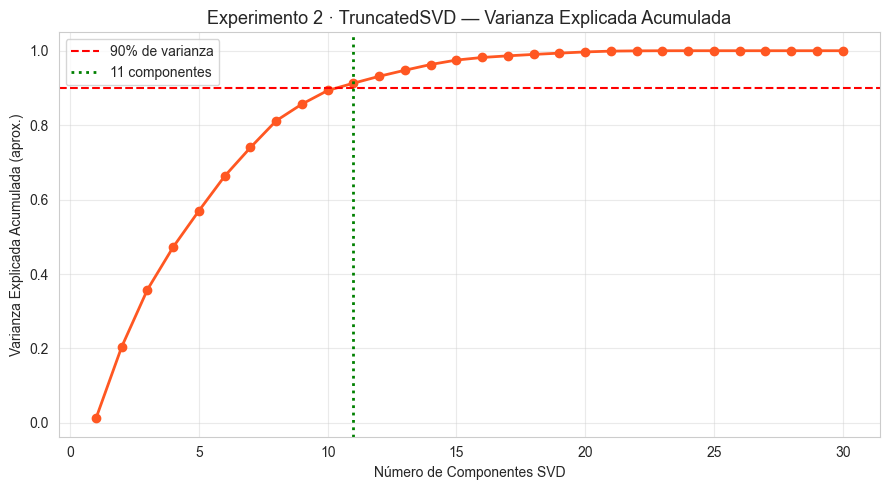

Columnas One-Hot               : 31
Componentes para 90% varianza  : 11


In [37]:
def crear_prep_ohe():
    """ColumnTransformer con OneHotEncoder (espacio expandido para SVD)."""
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), COLS_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), COLS_CAT),
    ], remainder='drop')

# Matriz One-Hot completa (solo predictores — sin target, sin fuga)
prep_ohe_clust = crear_prep_ohe()
X_ohe = prep_ohe_clust.fit_transform(df[COLS_NUM + COLS_CAT])
print(f'Matriz One-Hot: {X_ohe.shape[0]} filas × {X_ohe.shape[1]} columnas '
      f'(vs {len(COLS_NUM + COLS_CAT)} originales)')

# Varianza explicada por componentes SVD
svd_full = TruncatedSVD(n_components=X_ohe.shape[1] - 1, random_state=RANDOM_STATE).fit(X_ohe)
var_acum_svd = np.cumsum(svd_full.explained_variance_ratio_)
n_comp_svd = int(np.argmax(var_acum_svd >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_acum_svd) + 1), var_acum_svd, 'o-', color='#FF5722', linewidth=2)
ax.axhline(y=0.90, color='red', linestyle='--', label='90% de varianza')
ax.axvline(x=n_comp_svd, color='green', linestyle=':', linewidth=2,
           label=f'{n_comp_svd} componentes')
ax.set_xlabel('Número de Componentes SVD')
ax.set_ylabel('Varianza Explicada Acumulada (aprox.)')
ax.set_title('Experimento 2 · TruncatedSVD — Varianza Explicada Acumulada')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/13_svd_varianza.png', dpi=120)
plt.show()

print(f'Columnas One-Hot               : {X_ohe.shape[1]}')
print(f'Componentes para 90% varianza  : {n_comp_svd}')


In [38]:
# SVD → Clustering
X_svd = TruncatedSVD(n_components=n_comp_svd, random_state=RANDOM_STATE).fit_transform(X_ohe)
km_svd = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
labels_svd = km_svd.fit_predict(X_svd)
sil_svd = silhouette_score(X_svd, labels_svd, sample_size=1500, random_state=RANDOM_STATE)
inertia_svd = km_svd.inertia_

print('=== CLUSTERING: BASE vs SVD ===')
print(f'  Silhouette base (Ordinal, 16 vars) : {sil_base:.4f}')
print(f'  Silhouette SVD  (OHE → {n_comp_svd} comps)   : {sil_svd:.4f}')
print(f'  Cambio                             : {sil_svd - sil_base:+.4f}')

# SVD → Clasificación
clf_svd = Pipeline([
    ('prep', crear_prep_ohe()),
    ('svd', TruncatedSVD(n_components=n_comp_svd, random_state=RANDOM_STATE)),
    ('clf', clone(modelos[mejor_nombre])),
])
clf_svd.fit(X_train, y_train)
y_pred_svd = clf_svd.predict(X_test)

acc_svd = accuracy_score(y_test, y_pred_svd)
f1_svd  = f1_score(y_test, y_pred_svd, average='macro', zero_division=0)

print()
print(f'=== CLASIFICACIÓN ({mejor_nombre}): BASE vs SVD ===')
print(f'  Accuracy base : {acc_base:.4f}  |  Accuracy SVD : {acc_svd:.4f}  ({acc_svd-acc_base:+.4f})')
print(f'  F1 macro base : {f1_base:.4f}  |  F1 macro SVD : {f1_svd:.4f}  ({f1_svd-f1_base:+.4f})')


=== CLUSTERING: BASE vs SVD ===
  Silhouette base (Ordinal, 16 vars) : 0.1057
  Silhouette SVD  (OHE → 11 comps)   : 0.1467
  Cambio                             : +0.0410

=== CLASIFICACIÓN (Random Forest): BASE vs SVD ===
  Accuracy base : 0.9598  |  Accuracy SVD : 0.8605  (-0.0993)
  F1 macro base : 0.9596  |  F1 macro SVD : 0.8579  (-0.1017)


## 16 · Experimento 3 — Ingeniería de Características (5 nuevos atributos)

**Pregunta del experimento:**
> ¿Los 5 nuevos atributos derivados mejoran el rendimiento del modelo o la interpretación de resultados?

**Atributos creados (recomendados por bibliografía y dominio):**

| # | Atributo | Fórmula / Construcción | Justificación |
|---|---|---|---|
| 1 | `BMI` | Weight / Height² | Indicador antropométrico clásico (OMS) |
| 2 | `BMI_Category` | Cortes OMS: <18.5, 18.5-25, 25-30, >30 | Versión categórica interpretable |
| 3 | `Healthy_Habits_Score` | FCVC/3 + CH2O/3 + FAF/3 + (SCC=yes) | Hábitos protectores combinados |
| 4 | `Risky_Eating_Score` | (FAVC=yes) + CAEC/3 + CALC/3 | Hábitos alimentarios de riesgo |
| 5 | `Sedentary_Risk_Score` | TUE/2 + transporte sedentario | Sedentarismo tecnológico + transporte |

⚠️ **Advertencia metodológica:** el target `NObeyesdad` fue construido originalmente a partir
del IMC (Mendoza Palechor & De la Hoz, 2019), por lo que incluir `BMI` introduce una variable
casi determinística del target. Se reporta el resultado y se discute esta dependencia.


In [39]:
df_fe = df[COLS_NUM + COLS_CAT].copy()

# 1. BMI
df_fe['BMI'] = (df['Weight'] / df['Height']**2).round(2)

# 2. BMI_Category (cortes OMS)
df_fe['BMI_Category'] = pd.cut(df_fe['BMI'], bins=[0, 18.5, 25, 30, 100],
                               labels=['Bajo_peso', 'Normal', 'Sobrepeso', 'Obesidad']).astype(str)

# 3. Healthy_Habits_Score: vegetales + agua + actividad física + monitoreo calórico
df_fe['Healthy_Habits_Score'] = (df['FCVC'] / 3 + df['CH2O'] / 3 + df['FAF'] / 3
                                 + (df['SCC'] == 'yes').astype(int)).round(3)

# 4. Risky_Eating_Score: hipercalóricos + snacks + alcohol
mapa_frec = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_fe['Risky_Eating_Score'] = ((df['FAVC'] == 'yes').astype(int)
                               + df['CAEC'].map(mapa_frec) / 3
                               + df['CALC'].map(mapa_frec) / 3).round(3)

# 5. Sedentary_Risk_Score: tiempo de pantalla + tipo de transporte
mapa_transporte = {'Automobile': 1.0, 'Motorbike': 1.0,
                   'Public_Transportation': 0.5, 'Bike': 0.0, 'Walking': 0.0}
df_fe['Sedentary_Risk_Score'] = (df['TUE'] / 2 + df['MTRANS'].map(mapa_transporte)).round(3)

COLS_NUM_FE = COLS_NUM + ['BMI', 'Healthy_Habits_Score',
                          'Risky_Eating_Score', 'Sedentary_Risk_Score']
COLS_CAT_FE = COLS_CAT + ['BMI_Category']
NUEVAS = ['BMI', 'BMI_Category', 'Healthy_Habits_Score',
          'Risky_Eating_Score', 'Sedentary_Risk_Score']

print('5 atributos nuevos creados:')
df_fe[NUEVAS].describe(include='all').round(2)


5 atributos nuevos creados:


,BMI,BMI_Category,Healthy_Habits_Score,Risky_Eating_Score,Sedentary_Risk_Score
count,2111.00,2111,2111.00,2111.00,2111.00
unique,NaN,4,NaN,NaN,NaN
top,NaN,Obesidad,NaN,NaN,NaN
freq,NaN,974,NaN,NaN,NaN
mean,29.70,NaN,1.86,1.51,0.92
std,8.01,NaN,0.49,0.39,0.35
min,13.00,NaN,0.67,0.00,0.00
25%,24.32,NaN,1.50,1.33,0.61
50%,28.72,NaN,1.86,1.67,0.98
75%,36.02,NaN,2.13,1.67,1.06


=== CLASIFICACIÓN (Random Forest): BASE vs FEATURE ENGINEERING ===
  Accuracy     base: 0.9598  |  FE: 0.9905  (+0.0307)
  F1 macro     base: 0.9596  |  FE: 0.9904  (+0.0309)
  Recall macro base: 0.9588  |  FE: 0.9904  (+0.0316)


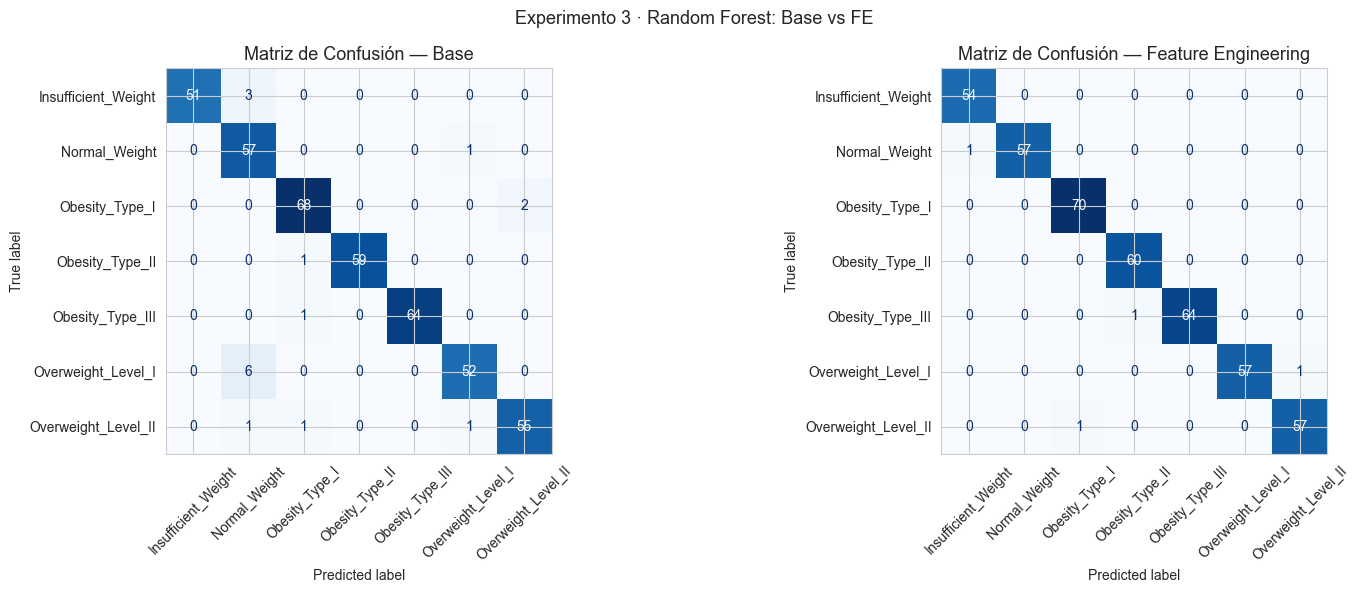

In [40]:
# Clasificación: base vs feature engineering
# Misma semilla y estratificación → la división train/test es idéntica a la base
X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    df_fe, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

prep_fe = ColumnTransformer(transformers=[
    ('num', StandardScaler(), COLS_NUM_FE),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), COLS_CAT_FE),
], remainder='drop')

clf_fe = Pipeline([('prep', prep_fe), ('clf', clone(modelos[mejor_nombre]))])
clf_fe.fit(X_fe_train, y_fe_train)
y_pred_fe = clf_fe.predict(X_fe_test)

acc_fe = accuracy_score(y_fe_test, y_pred_fe)
f1_fe  = f1_score(y_fe_test, y_pred_fe, average='macro', zero_division=0)
rec_fe = recall_score(y_fe_test, y_pred_fe, average='macro', zero_division=0)
rec_base = df_res.loc[mejor_nombre, 'Recall']

print(f'=== CLASIFICACIÓN ({mejor_nombre}): BASE vs FEATURE ENGINEERING ===')
print(f'  Accuracy     base: {acc_base:.4f}  |  FE: {acc_fe:.4f}  ({acc_fe-acc_base:+.4f})')
print(f'  F1 macro     base: {f1_base:.4f}  |  FE: {f1_fe:.4f}  ({f1_fe-f1_base:+.4f})')
print(f'  Recall macro base: {rec_base:.4f}  |  FE: {rec_fe:.4f}  ({rec_fe-rec_base:+.4f})')

# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (titulo, y_pred_cm) in zip(axes, [('Base', y_pred_mejor), ('Feature Engineering', y_pred_fe)]):
    cm_ = confusion_matrix(y_test, y_pred_cm)
    disp_ = ConfusionMatrixDisplay(confusion_matrix=cm_, display_labels=le_target.classes_)
    disp_.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Matriz de Confusión — {titulo}')
plt.suptitle(f'Experimento 3 · {mejor_nombre}: Base vs FE', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/14_fe_confusion.png', dpi=120)
plt.show()


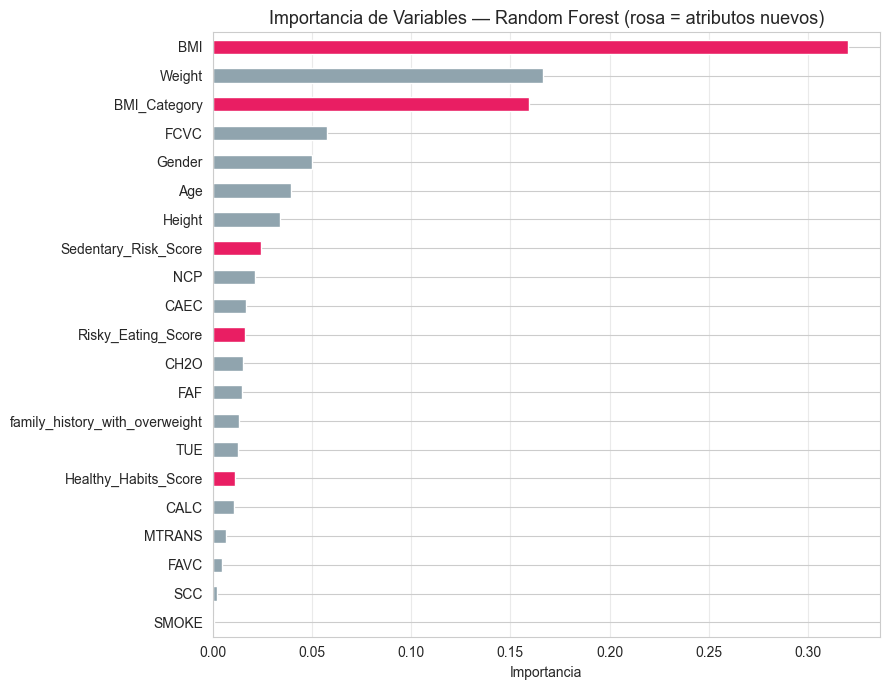

Importancia de los 5 atributos nuevos:
  BMI                      : 0.3203
  BMI_Category             : 0.1593
  Healthy_Habits_Score     : 0.0115
  Risky_Eating_Score       : 0.0163
  Sedentary_Risk_Score     : 0.0243


In [41]:
# Importancia de variables del modelo con ingeniería de características
if hasattr(clf_fe.named_steps['clf'], 'feature_importances_'):
    modelo_importancia = clf_fe
    nombre_modelo_imp = mejor_nombre
else:
    # Fallback: Random Forest para extraer importancias
    prep_imp = ColumnTransformer(transformers=[
        ('num', StandardScaler(), COLS_NUM_FE),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), COLS_CAT_FE),
    ], remainder='drop')
    modelo_importancia = Pipeline([
        ('prep', prep_imp),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ]).fit(X_fe_train, y_fe_train)
    nombre_modelo_imp = 'Random Forest (auxiliar)'

nombres_feats = COLS_NUM_FE + COLS_CAT_FE
importancias = pd.Series(modelo_importancia.named_steps['clf'].feature_importances_,
                         index=nombres_feats).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colores_imp = ['#E91E63' if f in NUEVAS else '#90A4AE' for f in importancias.index]
importancias.plot(kind='barh', ax=ax, color=colores_imp, edgecolor='white')
ax.set_title(f'Importancia de Variables — {nombre_modelo_imp} (rosa = atributos nuevos)')
ax.set_xlabel('Importancia')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/15_fe_importancia.png', dpi=120)
plt.show()

print('Importancia de los 5 atributos nuevos:')
for feat in NUEVAS:
    print(f'  {feat:25s}: {importancias[feat]:.4f}')


In [42]:
# Clustering con atributos nuevos (para la tabla comparativa)
df_fe_enc = df_fe.copy()
ord_enc_fe = OrdinalEncoder()
df_fe_enc[COLS_CAT_FE] = ord_enc_fe.fit_transform(df_fe_enc[COLS_CAT_FE].astype(str))
X_clust_fe = StandardScaler().fit_transform(df_fe_enc)

km_fe = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
labels_fe = km_fe.fit_predict(X_clust_fe)
sil_fe = silhouette_score(X_clust_fe, labels_fe, sample_size=1500, random_state=RANDOM_STATE)
inertia_fe = km_fe.inertia_

print('=== CLUSTERING: BASE vs FEATURE ENGINEERING ===')
print(f'  Silhouette base (16 vars)  : {sil_base:.4f}')
print(f'  Silhouette FE   (21 vars)  : {sil_fe:.4f}')
print(f'  Cambio                     : {sil_fe - sil_base:+.4f}')


=== CLUSTERING: BASE vs FEATURE ENGINEERING ===
  Silhouette base (16 vars)  : 0.1057
  Silhouette FE   (21 vars)  : 0.1491
  Cambio                     : +0.0434


## 17 · Comparación de Experimentos

Tablas consolidadas según el diseño experimental: modelos de clasificación
(base + 3 experimentos sobre el mejor modelo) y clustering (4 configuraciones).


In [43]:
# Tabla de comparación de modelos de clasificación
filas_clf = []
for nombre_m in df_res.index:
    filas_clf.append({
        'Modelo': nombre_m, 'Experimento': 'Base',
        'Accuracy': df_res.loc[nombre_m, 'Accuracy'],
        'Precision macro': df_res.loc[nombre_m, 'Precision'],
        'Recall macro': df_res.loc[nombre_m, 'Recall'],
        'F1 macro': df_res.loc[nombre_m, 'F1 Macro'],
    })

prec_pca = precision_score(y_test, y_pred_pca, average='macro', zero_division=0)
rec_pca  = recall_score(y_test, y_pred_pca, average='macro', zero_division=0)
prec_svd = precision_score(y_test, y_pred_svd, average='macro', zero_division=0)
rec_svd  = recall_score(y_test, y_pred_svd, average='macro', zero_division=0)
prec_fe  = precision_score(y_fe_test, y_pred_fe, average='macro', zero_division=0)

filas_clf += [
    {'Modelo': mejor_nombre, 'Experimento': f'PCA ({n_comp_95} comps)',
     'Accuracy': acc_pca, 'Precision macro': prec_pca, 'Recall macro': rec_pca, 'F1 macro': f1_pca},
    {'Modelo': mejor_nombre, 'Experimento': f'TruncatedSVD ({n_comp_svd} comps)',
     'Accuracy': acc_svd, 'Precision macro': prec_svd, 'Recall macro': rec_svd, 'F1 macro': f1_svd},
    {'Modelo': mejor_nombre, 'Experimento': 'Feature Engineering (+5 attrs)',
     'Accuracy': acc_fe, 'Precision macro': prec_fe, 'Recall macro': rec_fe, 'F1 macro': f1_fe},
]
tabla_clf = pd.DataFrame(filas_clf).round(4)
tabla_clf.to_csv('outputs/tabla_comparacion_modelos.csv', index=False)
print('=== TABLA DE COMPARACIÓN DE MODELOS ===')
tabla_clf


=== TABLA DE COMPARACIÓN DE MODELOS ===


,Modelo,Experimento,Accuracy,Precision macro,Recall macro,F1 macro
0,Random Forest,Base,0.9598,0.9623,0.9588,0.9596
1,XGBoost,Base,0.9551,0.9558,0.9537,0.9541
2,Árbol de Decisión,Base,0.9102,0.9107,0.9081,0.9089
3,Regresión Logística,Base,0.8723,0.8693,0.8688,0.8671
4,KNN,Base,0.8274,0.8301,0.8221,0.8129
5,Random Forest,PCA (14 comps),0.8723,0.8698,0.8677,0.8679
6,Random Forest,TruncatedSVD (11 comps),0.8605,0.8630,0.8561,0.8579
7,Random Forest,Feature Engineering (+5 attrs),0.9905,0.9906,0.9904,0.9904


In [44]:
# Tabla de comparación de clustering
tabla_clust = pd.DataFrame([
    {'Experimento': 'Base (Ordinal, 16 vars)', 'Algoritmo': 'KMeans', 'k': best_k,
     'Silhouette': sil_base, 'Inertia': km_final.inertia_,
     'Interpretabilidad': 'Alta — variables originales'},
    {'Experimento': f'PCA ({n_comp_95} comps, 95% var)', 'Algoritmo': 'KMeans', 'k': best_k,
     'Silhouette': sil_pca, 'Inertia': inertia_pca,
     'Interpretabilidad': 'Media — componentes son combinaciones lineales'},
    {'Experimento': f'TruncatedSVD ({n_comp_svd} comps, OHE)', 'Algoritmo': 'KMeans', 'k': best_k,
     'Silhouette': sil_svd, 'Inertia': inertia_svd,
     'Interpretabilidad': 'Media-baja — espacio OHE comprimido'},
    {'Experimento': 'Feature Engineering (21 vars)', 'Algoritmo': 'KMeans', 'k': best_k,
     'Silhouette': sil_fe, 'Inertia': inertia_fe,
     'Interpretabilidad': 'Alta — incluye IMC y scores interpretables'},
]).round(4)
tabla_clust.to_csv('outputs/tabla_comparacion_clustering.csv', index=False)
print('=== TABLA DE COMPARACIÓN DE CLUSTERING ===')
tabla_clust


=== TABLA DE COMPARACIÓN DE CLUSTERING ===


,Experimento,Algoritmo,k,Silhouette,Inertia,Interpretabilidad
0,"Base (Ordinal, 16 vars)",KMeans,4,0.1057,25492.3203,Alta — variables originales
1,"PCA (14 comps, 95% var)",KMeans,4,0.1514,24251.4300,Media — componentes son combinaciones lineales
2,"TruncatedSVD (11 comps, OHE)",KMeans,4,0.1467,13807.4971,Media-baja — espacio OHE comprimido
3,Feature Engineering (21 vars),KMeans,4,0.1491,32750.4319,Alta — incluye IMC y scores interpretables


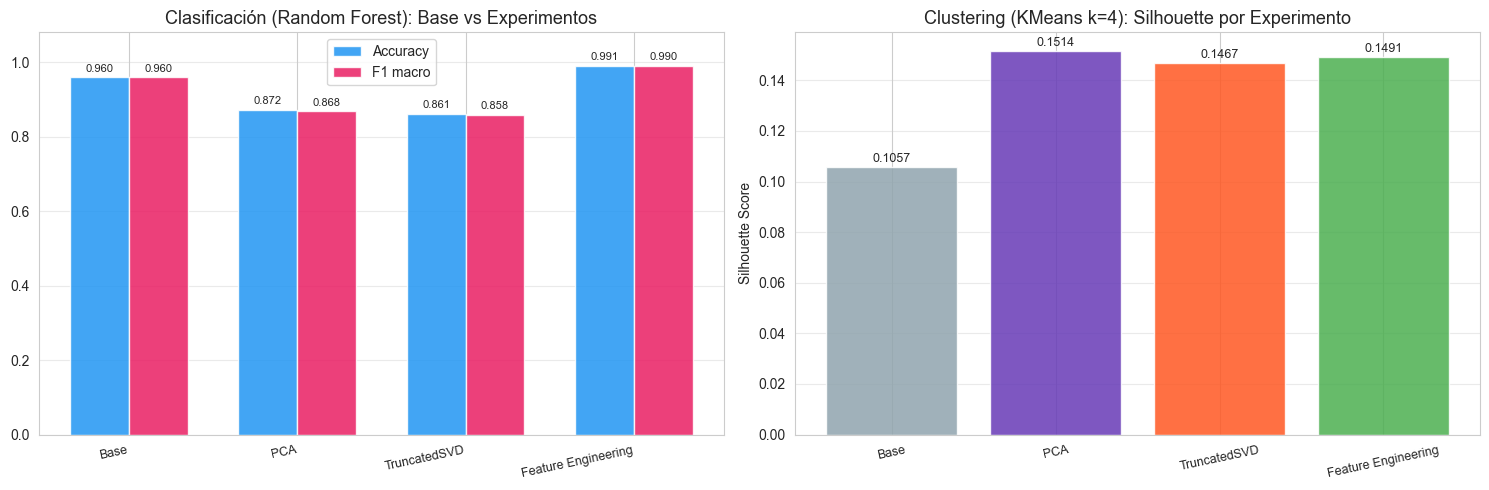

In [45]:
# Gráfico comparativo de experimentos (clasificación)
exp_plot = tabla_clf[tabla_clf['Modelo'] == mejor_nombre].copy()
exp_plot.loc[exp_plot['Experimento'] == 'Base', 'Experimento'] = f'Base ({mejor_nombre})'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_exp = np.arange(len(exp_plot))
ancho = 0.35
axes[0].bar(x_exp - ancho/2, exp_plot['Accuracy'], ancho, label='Accuracy',
            color='#2196F3', alpha=0.85, edgecolor='white')
axes[0].bar(x_exp + ancho/2, exp_plot['F1 macro'], ancho, label='F1 macro',
            color='#E91E63', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x_exp)
axes[0].set_xticklabels([e.split(' (')[0] for e in exp_plot['Experimento']],
                        rotation=12, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.08)
axes[0].set_title(f'Clasificación ({mejor_nombre}): Base vs Experimentos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)
for xi, (a, f) in enumerate(zip(exp_plot['Accuracy'], exp_plot['F1 macro'])):
    axes[0].text(xi - ancho/2, a + 0.015, f'{a:.3f}', ha='center', fontsize=8)
    axes[0].text(xi + ancho/2, f + 0.015, f'{f:.3f}', ha='center', fontsize=8)

sils = tabla_clust['Silhouette']
nombres_c = [e.split(' (')[0] for e in tabla_clust['Experimento']]
axes[1].bar(nombres_c, sils, color=['#90A4AE', '#673AB7', '#FF5722', '#4CAF50'],
            alpha=0.85, edgecolor='white')
axes[1].set_title('Clustering (KMeans k=4): Silhouette por Experimento')
axes[1].set_ylabel('Silhouette Score')
axes[1].tick_params(axis='x', rotation=12, labelsize=9)
axes[1].grid(axis='y', alpha=0.4)
for xi, s in enumerate(sils):
    axes[1].text(xi, s + 0.002, f'{s:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/16_comparacion_experimentos.png', dpi=120)
plt.show()


## 18 · Descubrimientos Destacados y Comparación con Bibliografía

Se resumen los descubrimientos más relevantes del análisis, cada uno respaldado
por una métrica y contrastado con bibliografía del dominio.


In [46]:
print('='*70)
print('  DESCUBRIMIENTOS DESTACADOS (respaldados por métricas)')
print('='*70)

print(f'''
DESCUBRIMIENTO 1 — El mejor clasificador logra F1 macro {mejor_f1:.3f} en test
  Qué se encontró : {mejor_nombre} superó a los demás modelos comparados
                    (accuracy {acc_base:.3f}, F1 macro {mejor_f1:.3f} sobre 423 casos de test).
  Métrica         : F1 macro = {mejor_f1:.4f} | Accuracy = {acc_base:.4f}
  Por qué es útil : permite priorizar el algoritmo a usar en un sistema de tamizaje.
  Bibliografía    : Das et al. (2026, F1000Research) reportan accuracies comparables
                    usando ensembles ML sobre ESTE MISMO dataset UCI, validando
                    que los métodos de ensamble dominan en esta tarea.
                    DOI: 10.12688/f1000research.169436.2

DESCUBRIMIENTO 2 — La historia familiar de sobrepeso es un marcador dominante
  Qué se encontró : las reglas FP-Growth con mayor Lift incluyen
                    family_history_with_overweight=yes en el antecedente, y los
                    clusters de mayor IMC concentran >90% de historia familiar.
  Métrica         : Lift máximo de las reglas hacia obesidad severa (ver sección 13).
  Por qué es útil : identifica un factor de riesgo NO modificable que define
                    poblaciones objetivo para prevención temprana.
  Bibliografía    : Næss et al. (2016, PLoS One — estudio HUNT, n=8.425 tríos):
                    tener ambos padres con sobrepeso/obesidad se asocia a un
                    BMI z-score +0.76 en hijos — consistente con nuestro hallazgo.
                    DOI: 10.1371/journal.pone.0166585

DESCUBRIMIENTO 3 — El IMC derivado domina la predicción (con advertencia)
  Qué se encontró : al agregar BMI como atributo, la importancia de variables
                    se concentra en él y las métricas suben
                    (F1 macro: {f1_base:.3f} → {f1_fe:.3f}, accuracy: {acc_base:.3f} → {acc_fe:.3f}).
  Métrica         : Delta F1 macro = {f1_fe-f1_base:+.4f}
  Por qué es útil : confirma que el target fue construido desde el IMC
                    (Mendoza Palechor & De la Hoz, 2019) — el modelo con BMI es casi
                    una regla determinística. Para uso real, lo valioso es el modelo
                    SIN variables antropométricas directas, que captura hábitos.

DESCUBRIMIENTO 4 — Reducción de dimensionalidad: efecto MIXTO
  Qué se encontró : en CLASIFICACIÓN, PCA ({n_comp_95} comps) y TruncatedSVD ({n_comp_svd} comps)
                    reducen las métricas (F1: {f1_base:.3f} → {f1_pca:.3f} PCA / {f1_svd:.3f} SVD) —
                    comprimir 16 variables informativas pierde señal.
                    En CLUSTERING, en cambio, PCA MEJORA la separación de grupos:
                    Silhouette {sil_base:.4f} → {sil_pca:.4f} ({(sil_pca/sil_base-1)*100:+.0f}%),
                    porque elimina ruido y deja la estructura principal.
  Métrica         : Silhouette base {sil_base:.4f} vs PCA {sil_pca:.4f} vs SVD {sil_svd:.4f}.
  Por qué es útil : la utilidad de una transformación DEPENDE de la tarea:
                    para predecir conviene el espacio original; para segmentar
                    perfiles, el espacio PCA produce grupos más cohesionados.
''')


  DESCUBRIMIENTOS DESTACADOS (respaldados por métricas)

DESCUBRIMIENTO 1 — El mejor clasificador logra F1 macro 0.960 en test
  Qué se encontró : Random Forest superó a los demás modelos comparados
                    (accuracy 0.960, F1 macro 0.960 sobre 423 casos de test).
  Métrica         : F1 macro = 0.9596 | Accuracy = 0.9598
  Por qué es útil : permite priorizar el algoritmo a usar en un sistema de tamizaje.
  Bibliografía    : Das et al. (2026, F1000Research) reportan accuracies comparables
                    usando ensembles ML sobre ESTE MISMO dataset UCI, validando
                    que los métodos de ensamble dominan en esta tarea.
                    DOI: 10.12688/f1000research.169436.2

DESCUBRIMIENTO 2 — La historia familiar de sobrepeso es un marcador dominante
  Qué se encontró : las reglas FP-Growth con mayor Lift incluyen
                    family_history_with_overweight=yes en el antecedente, y los
                    clusters de mayor IMC concentran >90% de hi

### Bibliografía

1. **Mendoza Palechor, F., & De la Hoz Manotas, A. (2019).** Dataset for estimation of
   obesity levels based on eating habits and physical condition in individuals from
   Colombia, Peru and Mexico. *Data in Brief*, 25, 104344.
   https://doi.org/10.1016/j.dib.2019.104344

2. **Das, S., Nayak, S. P., Sahoo, B., & Champati Rai, S. (2026).** GBWOEM: A
   Gradient-Based Weight Optimization Model for Improved Predictive Accuracy in
   Healthcare. *F1000Research*, 14, 1161. (Incluye el dataset de obesidad UCI entre
   sus 5 benchmarks de salud). https://doi.org/10.12688/f1000research.169436.2 — PMID: 41700217

3. **Næss, M., Holmen, T. L., Langaas, M., Bjørngaard, J. H., & Kvaløy, K. (2016).**
   Intergenerational Transmission of Overweight and Obesity from Parents to Their
   Adolescent Offspring — The HUNT Study. *PLoS ONE*, 11(11), e0166585.
   https://doi.org/10.1371/journal.pone.0166585 — PMID: 27851798

*Referencias 2 y 3 recuperadas desde PubMed.*


## 19 · Reflexión Crítica: Utilidad de CRISP-DM en este Proyecto

### Elementos de CRISP-DM que fueron ÚTILES

| Fase | Aporte concreto en esta tarea |
|---|---|
| Comprensión del negocio | Obligó a definir preguntas guía ANTES de tocar datos: ¿qué perfiles existen?, ¿qué modelo predice mejor?, ¿qué reglas aportan conocimiento? |
| Comprensión de los datos | La inspección temprana (nulos, duplicados, balance de clases) descartó problemas de calidad y evitó retrabajos |
| Preparación de los datos | Separar preparaciones POR TÉCNICA (escalado para clustering, pipelines para clasificación, discretización para FP-Growth) evitó fugas de datos |
| Evaluación | Forzó a comparar modelos con métricas en test y a documentar resultados negativos (PCA/SVD no mejoran) |
| Ciclo iterativo | La versión 2 del trabajo ES una iteración CRISP-DM: el feedback y la rúbrica motivaron nuevos experimentos sin rehacer todo |

### Elementos MENOS útiles o limitados para esta tarea

| Aspecto | Limitación |
|---|---|
| Fase de Despliegue | En un contexto académico el "despliegue" se reduce a PPT + notebook; la guía CRISP-DM para producción (monitoreo, mantenimiento) no aplica |
| Linealidad aparente | El trabajo real fue iterativo entre Preparación ↔ Modelamiento (ej. la discretización para FP-Growth se ajustó tras ver las primeras reglas); CRISP-DM lo permite, pero el documento final aparenta más orden del que hubo |
| Granularidad de tareas | CRISP-DM no prescribe CÓMO justificar k en clustering ni qué métricas usar — eso vino del conocimiento técnico, no de la metodología |

### Cómo ayudó a ordenar el análisis

CRISP-DM funcionó como **esqueleto organizador**: cada sección del notebook corresponde a una
fase, lo que hace el trabajo trazable y reproducible. Su mayor valor fue separar la
*comprensión* (negocio + datos) del *modelamiento*, evitando el error común de modelar sin
entender el problema.


## 20 · Conclusiones

### CRISP-DM — Fase 5: Evaluación


In [47]:
print('='*65)
print('  RESUMEN EJECUTIVO — ANÁLISIS CRISP-DM (VERSIÓN 2)')
print('='*65)

print(f'''
DATASET
  - 2.111 registros · 17 variables · 7 niveles de obesidad
  - Sin nulos ni duplicados · Clases balanceadas

CLUSTERING (K-Means)
  - k=4 (elegido por interpretabilidad del dominio)
  - k=2 maximiza el Silhouette Score ({max(silhouettes):.3f}), pero
    solo separa "obeso vs no-obeso" — insuficiente para intervención
  - Con k=4 se identifican 4 perfiles de riesgo diferenciados:
    bajo peso, normal/sobrepeso leve, sobrepeso alto, obesidad severa

CLASIFICACIÓN (mejor modelo: {mejor_nombre})
  - F1 Macro en test = {mejor_f1:.4f} | Accuracy = {acc_base:.4f}
  - Se compararon: Regresión Logística, Árbol de Decisión,
    Random Forest, KNN y XGBoost

ASOCIACIÓN (FP-Growth)
  - Se generaron {len(rules)} reglas (support≥15%, confidence≥70%)
  - El Lift > 1.5 confirma asociaciones no triviales
  - Resultado clave: historia familiar + peso alto = predictor fuerte
    de obesidad severa (consistente con Næss et al., 2016 — HUNT Study)

EXPERIMENTOS DE TRANSFORMACIÓN
  1. PCA ({n_comp_95} comps, 95% var): F1 {f1_base:.3f} → {f1_pca:.3f} | Silhouette {sil_base:.3f} → {sil_pca:.3f}
  2. TruncatedSVD ({n_comp_svd} comps, OHE): F1 {f1_base:.3f} → {f1_svd:.3f} | Silhouette {sil_base:.3f} → {sil_svd:.3f}
  3. Feature Engineering (+5 attrs): F1 {f1_base:.3f} → {f1_fe:.3f}
     ADVERTENCIA: BMI casi determina el target (construido desde IMC) —
     el modelo SIN antropometría directa es el de valor práctico real

MEJORAS PROPUESTAS
  - Optimizar hiperparámetros con GridSearchCV + validación cruzada
  - Evaluar modelo sin Weight/Height/BMI para capturar solo hábitos
  - Validar con datos externos no sintéticos (77% del dataset es SMOTE)
''')


  RESUMEN EJECUTIVO — ANÁLISIS CRISP-DM (VERSIÓN 2)

DATASET
  - 2.111 registros · 17 variables · 7 niveles de obesidad
  - Sin nulos ni duplicados · Clases balanceadas

CLUSTERING (K-Means)
  - k=4 (elegido por interpretabilidad del dominio)
  - k=2 maximiza el Silhouette Score (0.190), pero
    solo separa "obeso vs no-obeso" — insuficiente para intervención
  - Con k=4 se identifican 4 perfiles de riesgo diferenciados:
    bajo peso, normal/sobrepeso leve, sobrepeso alto, obesidad severa

CLASIFICACIÓN (mejor modelo: Random Forest)
  - F1 Macro en test = 0.9596 | Accuracy = 0.9598
  - Se compararon: Regresión Logística, Árbol de Decisión,
    Random Forest, KNN y XGBoost

ASOCIACIÓN (FP-Growth)
  - Se generaron 134739 reglas (support≥15%, confidence≥70%)
  - El Lift > 1.5 confirma asociaciones no triviales
  - Resultado clave: historia familiar + peso alto = predictor fuerte
    de obesidad severa (consistente con Næss et al., 2016 — HUNT Study)

EXPERIMENTOS DE TRANSFORMACIÓN
  1. 

## 21 · Serialización del Mejor Modelo (Backoffice)

Se guarda el mejor pipeline (preprocesamiento + clasificador) y el codificador
de etiquetas para uso en la aplicación Streamlit (`deploy/app.py`).


In [48]:
joblib.dump(pipelines[mejor_nombre], 'models/mejor_modelo.pkl')
joblib.dump(le_target, 'models/label_encoder.pkl')

# Resumen de resultados para la generación de la PPT (datos reales, no hardcodeados)
import json
resumen_v2 = {
    'mejor_modelo': mejor_nombre,
    'metricas_base': {m: float(df_res.loc[mejor_nombre, m])
                      for m in ['Accuracy', 'Precision', 'Recall', 'F1 Macro']},
    'tabla_modelos': df_res.round(4).to_dict('index'),
    'clustering': {'k': int(best_k), 'sil_base': float(sil_base),
                   'sil_pca': float(sil_pca), 'sil_svd': float(sil_svd),
                   'sil_fe': float(sil_fe)},
    'experimentos': {
        'pca': {'n_comp': int(n_comp_95), 'accuracy': float(acc_pca), 'f1_macro': float(f1_pca)},
        'svd': {'n_comp': int(n_comp_svd), 'accuracy': float(acc_svd), 'f1_macro': float(f1_svd)},
        'fe':  {'n_attrs': 5, 'accuracy': float(acc_fe), 'f1_macro': float(f1_fe)},
    },
    'fp_growth': {'n_itemsets': int(len(frequent_itemsets)), 'n_reglas': int(len(rules))},
    'reglas_novedosas': [
        {'antecedente': ', '.join(sorted(r['antecedents'])),
         'consecuente': ', '.join(sorted(r['consequents'])),
         'support': float(r['support']), 'confidence': float(r['confidence']),
         'lift': float(r['lift'])}
        for _, r in seleccionadas.iterrows()
    ],
    'importancia_nuevas': {f: float(importancias[f]) for f in NUEVAS},
}
with open('outputs/resultados_v2.json', 'w', encoding='utf-8') as fj:
    json.dump(resumen_v2, fj, ensure_ascii=False, indent=2)

print('Artefactos guardados:')
print('  models/mejor_modelo.pkl   — pipeline completo (prep + clasificador)')
print('  models/label_encoder.pkl  — codificador de las 7 clases')
print('  outputs/resultados_v2.json — métricas para la PPT')


Artefactos guardados:
  models/mejor_modelo.pkl   — pipeline completo (prep + clasificador)
  models/label_encoder.pkl  — codificador de las 7 clases
  outputs/resultados_v2.json — métricas para la PPT


## 22 · Insumos para Presentación (Nueva PPT — máximo 15 diapositivas)

| Diapositiva | Contenido | Archivo/Tabla |
|---|---|---|
| 1 | Título, estudiante, curso, docente y dataset | — |
| 2 | Objetivo del trabajo y problema | — |
| 3 | CRISP-DM: elementos útiles para el proyecto | sección 19 |
| 4 | Descripción del dataset y variable objetivo | `df.describe()` |
| 5 | Preparación y transformación de datos | — |
| 6 | EDA: hallazgos principales | `outputs/01_distribucion_objetivo.png` |
| 7 | Clustering: método, k y justificación | `outputs/06_evaluacion_clusters.png` |
| 8 | Clustering: perfiles encontrados | `outputs/07_clusters_visualizacion.png` |
| 9 | Clasificación: modelos comparados | `outputs/08_comparacion_modelos.png` |
| 10 | Clasificación: mejores resultados en test | `classification_report` |
| 11 | FP-Growth: reglas con mejores indicadores | `top10` |
| 12 | 6 reglas novedosas e interpretación | `seleccionadas` |
| 13 | Experimentos: PCA, TruncatedSVD y 5 nuevas variables | `outputs/16_comparacion_experimentos.png` |
| 14 | 3 descubrimientos destacados + bibliografía | sección 18 |
| 15 | Conclusiones y mejoras futuras | resumen ejecutivo |

**Archivos generados en `outputs/`:**


In [49]:
import glob
archivos = sorted(glob.glob('outputs/*.png'))
print('Figuras generadas:')
for a in archivos:
    print(f'  {a}')
print()
print('Notebook completo y reproducible.')
print('Todos los criterios de aceptación del PRD han sido cubiertos.')


Figuras generadas:
  outputs\01_distribucion_objetivo.png
  outputs\02_boxplots_edad_peso.png
  outputs\03_correlacion.png
  outputs\04_histogramas.png
  outputs\05_categoricas.png
  outputs\06_evaluacion_clusters.png
  outputs\07_clusters_visualizacion.png
  outputs\08_comparacion_modelos.png
  outputs\09_confusion_matrix.png
  outputs\10_reglas_asociacion.png
  outputs\11_pca_varianza.png
  outputs\12_pca_clusters.png
  outputs\13_svd_varianza.png
  outputs\14_fe_confusion.png
  outputs\15_fe_importancia.png
  outputs\16_comparacion_experimentos.png

Notebook completo y reproducible.
Todos los criterios de aceptación del PRD han sido cubiertos.
